In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

import sys
from pathlib import Path

parent_dir = Path.cwd().parent
sys.path.append(str(parent_dir))

from importlib import reload
import kan
reload(kan)

from kan import KAN

# One input-one output function approximation task

## Regression sanity test

This test checks whether the tanh-basis KAN can learn a simple nonlinear mapping before moving to more complex tasks.

The model is trained on a 2D regression problem with positive inputs $x_1, x_2 \in (0,1]$, using the target function

$$
y = \sin(3x_1x_2) + 0.2x_1 + 0.1x_2^2
$$

This is a useful sanity check because it is small, easy to visualize, and still contains a nonlinear interaction term.  
I compare a shallow KAN and a KAN with one hidden layer, and I inspect the hidden activations to understand why deeper versions may fail or succeed.

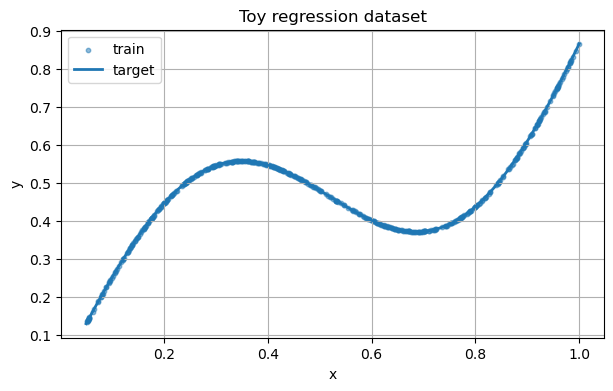

In [14]:
torch.manual_seed(42)

# Positive inputs in (0, 1]
n_train = 512
n_test = 200

x_train = 0.05 + 0.95 * torch.rand(n_train, 1)
x_test = torch.linspace(0.05, 1.0, n_test).unsqueeze(1)

# A smooth nonlinear target
def target_fn(x):
    return 0.8 * x + 0.3 * torch.sin(6.0 * x) + 0.15 * x**2

y_train = target_fn(x_train)
y_test = target_fn(x_test)

plt.figure(figsize=(7, 4))
plt.scatter(x_train.numpy(), y_train.numpy(), s=10, alpha=0.5, label="train")
plt.plot(x_test.numpy(), y_test.numpy(), linewidth=2, label="target")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Toy regression dataset")
plt.legend()
plt.grid(True)
plt.show()

In [15]:
model = KAN(
    in_count=1,
    out_count=1,
    hidden_layer_sizes=[],
    num_basis=12,
    x_min=0.0,
    x_max=1.0,
    gamma_scale=3.0,
    debug=False,
)

print(model)

KAN(
  (layers): ModuleList(
    (0): TanhBasisActivationLayer()
  )
)


In [16]:
optimizer = optim.Adam(model.parameters(), lr=1e-2)
loss_fn = nn.MSELoss()

num_epochs = 2000
losses = []

for epoch in range(num_epochs):
    model.train()

    optimizer.zero_grad()
    y_pred = model(x_train)
    loss = loss_fn(y_pred, y_train)
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    if epoch % 200 == 0:
        print(f"Epoch {epoch:4d} | Loss = {loss.item():.6f}")

Epoch    0 | Loss = 0.241149
Epoch  200 | Loss = 0.000076
Epoch  400 | Loss = 0.000054
Epoch  600 | Loss = 0.000049
Epoch  800 | Loss = 0.000048
Epoch 1000 | Loss = 0.000048
Epoch 1200 | Loss = 0.000048
Epoch 1400 | Loss = 0.000048
Epoch 1600 | Loss = 0.000048
Epoch 1800 | Loss = 0.000048


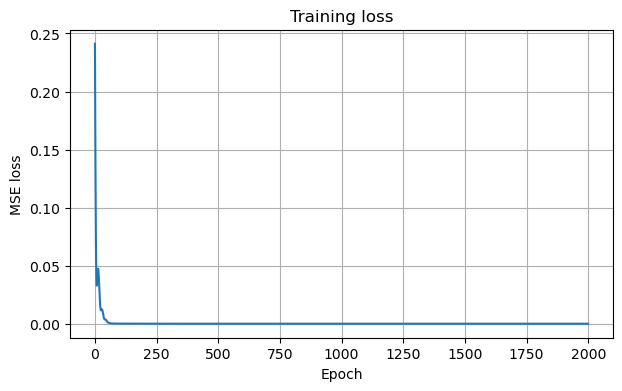

In [17]:
plt.figure(figsize=(7, 4))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Training loss")
plt.grid(True)
plt.show()

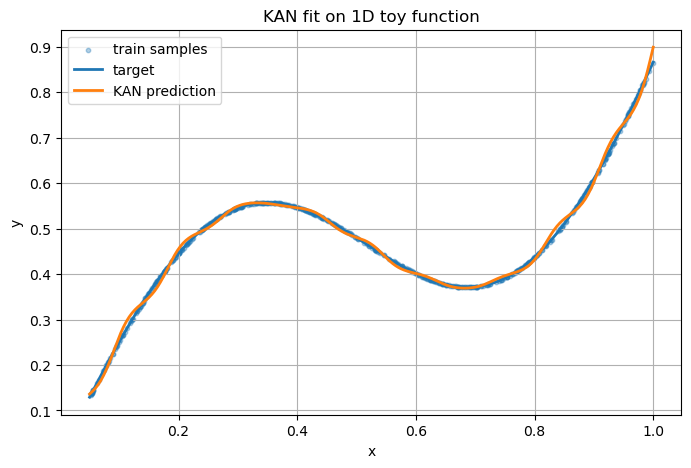

In [18]:
model.eval()
with torch.no_grad():
    y_pred_test = model(x_test)

plt.figure(figsize=(8, 5))
plt.scatter(x_train.numpy(), y_train.numpy(), s=10, alpha=0.35, label="train samples")
plt.plot(x_test.numpy(), y_test.numpy(), linewidth=2, label="target")
plt.plot(x_test.numpy(), y_pred_test.numpy(), linewidth=2, label="KAN prediction")
plt.xlabel("x")
plt.ylabel("y")
plt.title("KAN fit on 1D toy function")
plt.legend()
plt.grid(True)
plt.show()

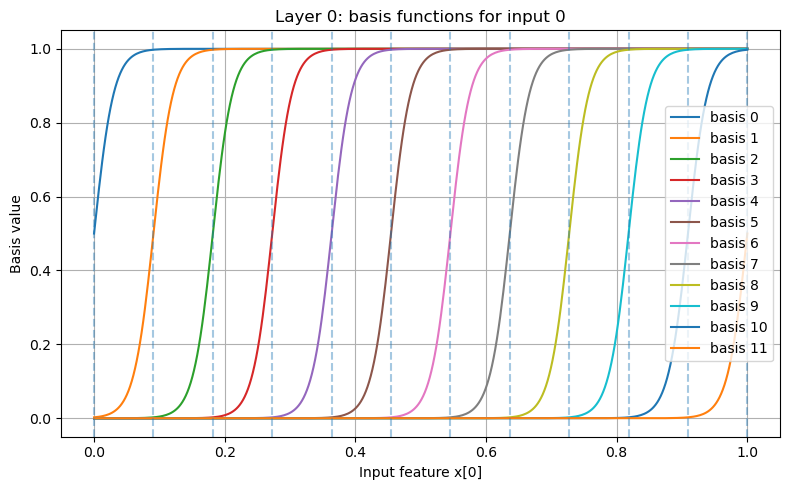

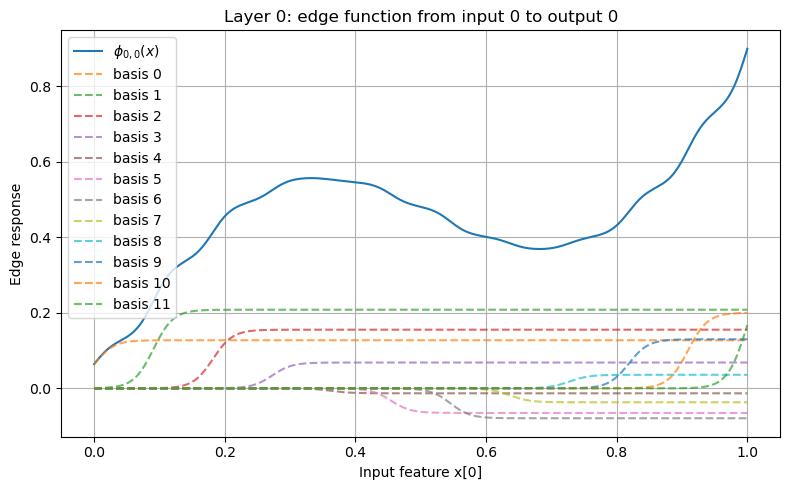

Layer 0 coefficient tensor shape: (1, 1, 12)
  min  = -0.079107
  max  = 0.335364
  mean = 0.088955
  std  = 0.126640


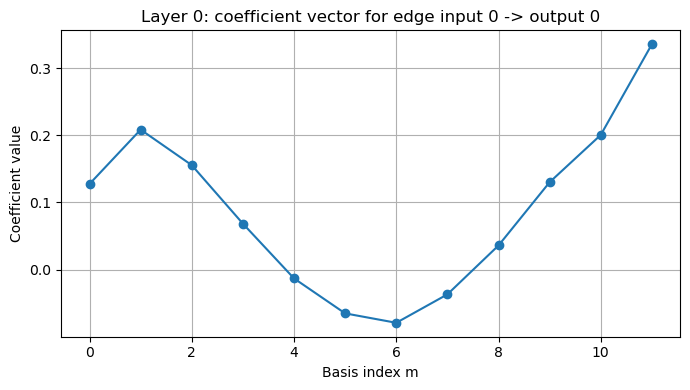

In [19]:
model.plot_basis_functions(
    layer_idx=0,
    in_idx=0,
    x_range=(0.0, 1.0),
)

model.plot_edge_function(
    layer_idx=0,
    out_idx=0,
    in_idx=0,
    x_range=(0.0, 1.0),
    show_basis=True,
)

model.print_coeff_stats(layer_idx=0)
model.plot_coefficient_vector(layer_idx=0, out_idx=0, in_idx=0)

## Multi-input, multi-output regression test

This test evaluates the tanh-basis KAN on a simple 2D regression task with two outputs.  
The inputs satisfy $x_1, x_2 \in (0,1]$, and the target functions are

$$
y_1 = \sin(4x_1) + 0.5x_2^2
$$

$$
y_2 = 0.3x_1^2 + \cos(3x_2)
$$

These targets are nonlinear but still additive across input coordinates, which matches the structure of a one-layer KAN:
$$
y_j = \sum_i \varphi_{ij}(x_i)
$$

In [127]:
torch.manual_seed(42)

n_train = 1000
n_test = 300

x_train = 0.05 + 10.0 * torch.rand(n_train, 2)
x_test = 0.05 + 10.0 * torch.rand(n_test, 2)

def target_fn(x):
    x1 = x[:, 0:1]
    x2 = x[:, 1:2]

    y1 = torch.sin(4.0 * x1) + 0.5 * x2**2
    y2 = 0.3 * x1**2 + torch.cos(3.0 * x2)

    return torch.cat([y1, y2], dim=1)

y_train = target_fn(x_train)
y_test = target_fn(x_test)

In [128]:
model = KAN(
    in_count=2,
    out_count=2,
    hidden_layer_sizes=[],
    num_basis=12,
    x_min=0.0,
    x_max=60.0,
    gamma_scale=3.0,
    debug=False,
)

optimizer = optim.Adam(model.parameters(), lr=1e-2)
loss_fn = nn.MSELoss()

In [129]:
num_epochs = 2500
train_losses = []
test_losses = []

for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()

    y_pred = model(x_train)
    loss = loss_fn(y_pred, y_train)
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        y_test_pred = model(x_test)
        test_loss = loss_fn(y_test_pred, y_test)

    train_losses.append(loss.item())
    test_losses.append(test_loss.item())

    if epoch % 250 == 0:
        print(f"Epoch {epoch:4d} | train loss = {loss.item():.6f} | test loss = {test_loss.item():.6f}")

Epoch    0 | train loss = 339.104462 | test loss = 312.938171
Epoch  250 | train loss = 186.315414 | test loss = 166.606064
Epoch  500 | train loss = 123.899651 | test loss = 109.798569
Epoch  750 | train loss = 97.753792 | test loss = 88.101295
Epoch 1000 | train loss = 83.314041 | test loss = 76.537415
Epoch 1250 | train loss = 72.227898 | test loss = 67.077568
Epoch 1500 | train loss = 62.394444 | test loss = 58.197212
Epoch 1750 | train loss = 53.529072 | test loss = 49.980236
Epoch 2000 | train loss = 45.629505 | test loss = 42.578571
Epoch 2250 | train loss = 38.680393 | test loss = 36.029675


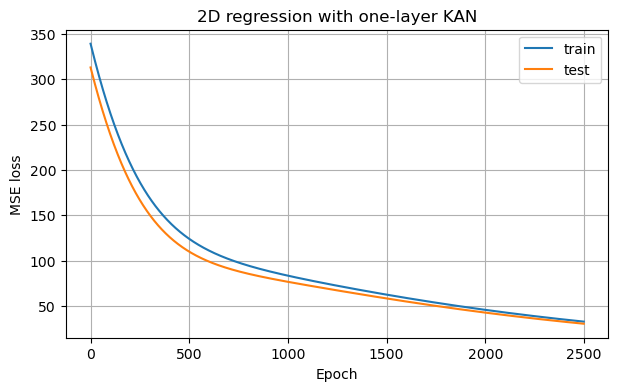

In [130]:
plt.figure(figsize=(7, 4))
plt.plot(train_losses, label="train")
plt.plot(test_losses, label="test")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("2D regression with one-layer KAN")
plt.legend()
plt.grid(True)
plt.show()

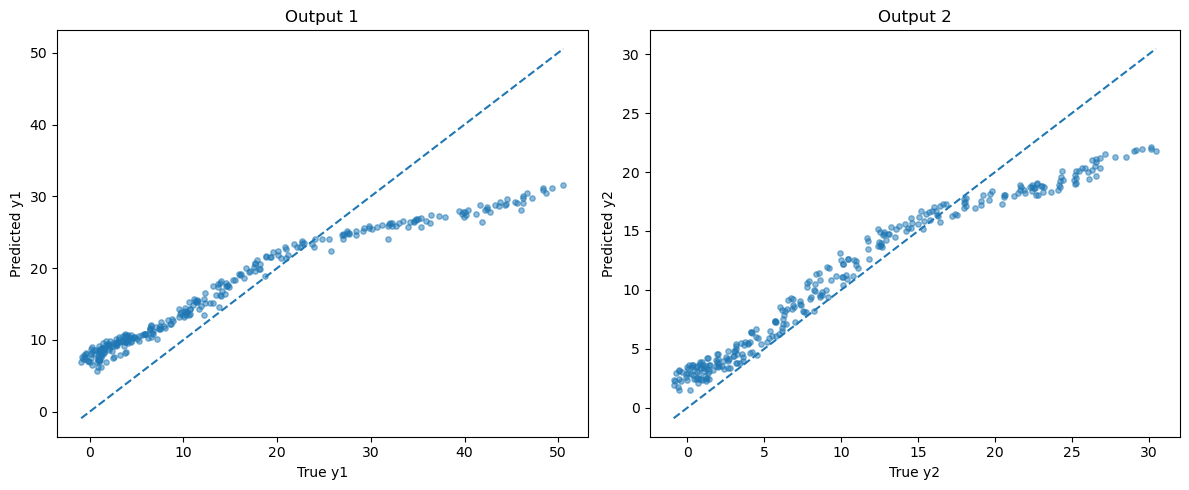

In [131]:
model.eval()
with torch.no_grad():
    y_pred_test = model(x_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for j in range(2):
    axes[j].scatter(y_test[:, j].numpy(), y_pred_test[:, j].numpy(), alpha=0.5, s=15)
    minv = min(y_test[:, j].min().item(), y_pred_test[:, j].min().item())
    maxv = max(y_test[:, j].max().item(), y_pred_test[:, j].max().item())
    axes[j].plot([minv, maxv], [minv, maxv], linestyle="--")
    axes[j].set_xlabel(f"True y{j+1}")
    axes[j].set_ylabel(f"Predicted y{j+1}")
    axes[j].set_title(f"Output {j+1}")

plt.tight_layout()
plt.show()

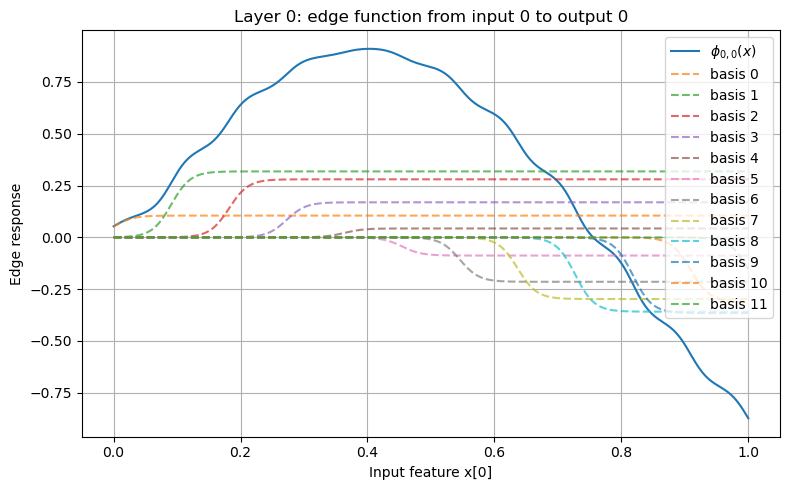

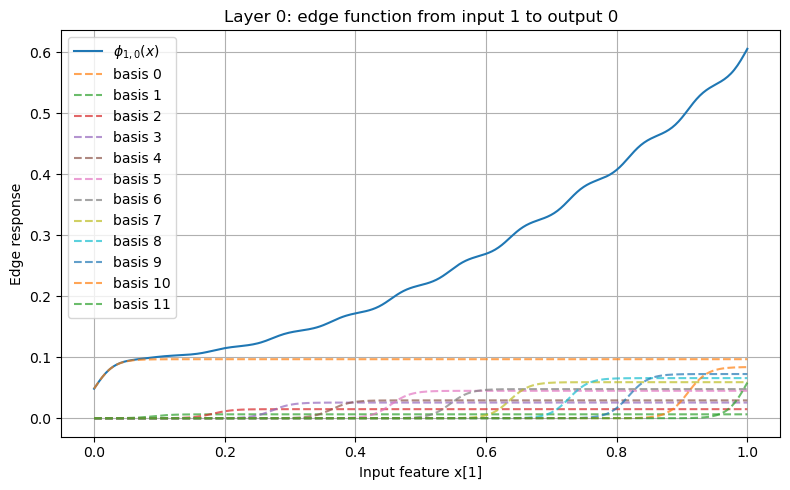

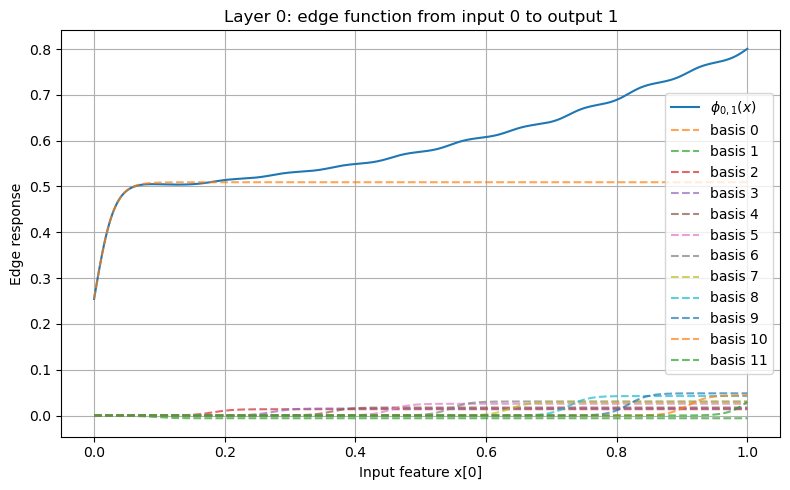

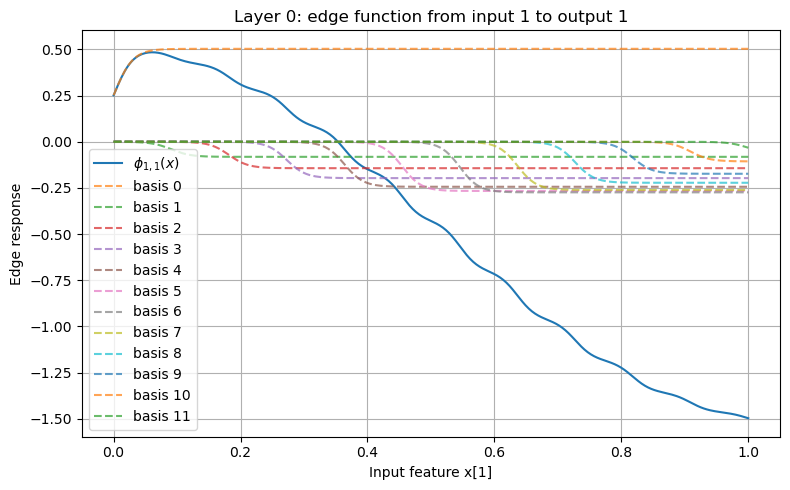

In [25]:
model.plot_edge_function(layer_idx=0, out_idx=0, in_idx=0, x_range=(0.0, 1.0), show_basis=True)
model.plot_edge_function(layer_idx=0, out_idx=0, in_idx=1, x_range=(0.0, 1.0), show_basis=True)
model.plot_edge_function(layer_idx=0, out_idx=1, in_idx=0, x_range=(0.0, 1.0), show_basis=True)
model.plot_edge_function(layer_idx=0, out_idx=1, in_idx=1, x_range=(0.0, 1.0), show_basis=True)

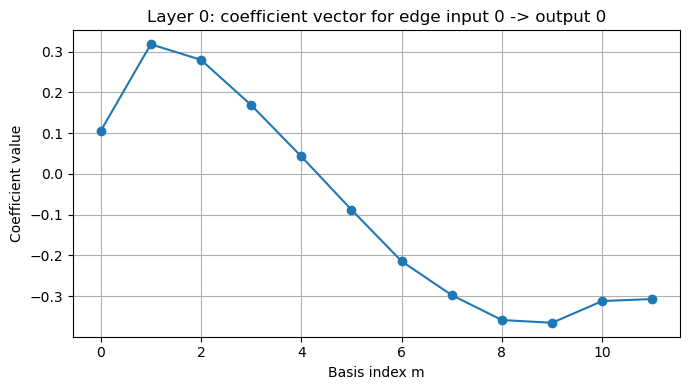

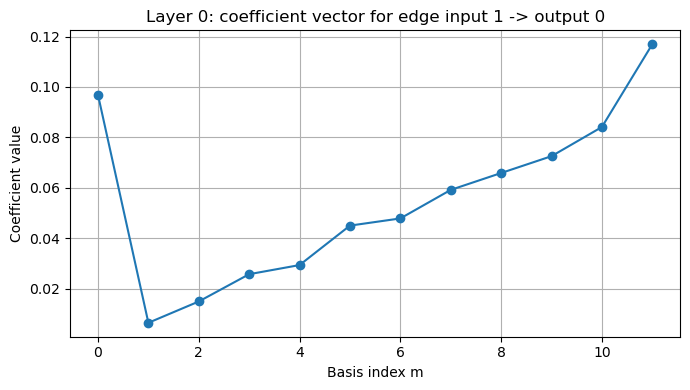

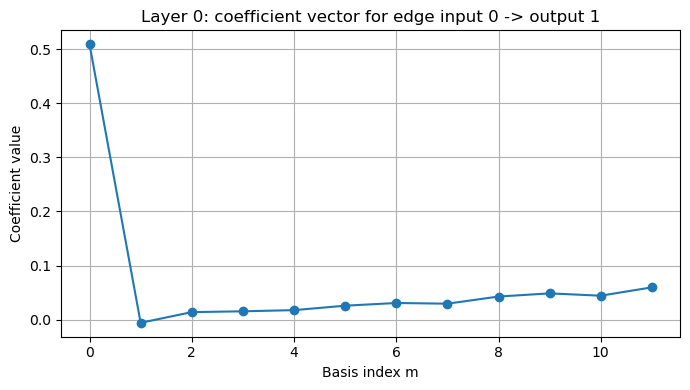

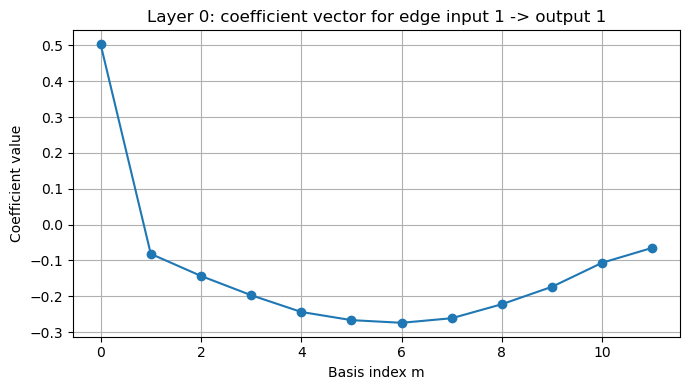

In [26]:
model.plot_coefficient_vector(layer_idx=0, out_idx=0, in_idx=0)
model.plot_coefficient_vector(layer_idx=0, out_idx=0, in_idx=1)
model.plot_coefficient_vector(layer_idx=0, out_idx=1, in_idx=0)
model.plot_coefficient_vector(layer_idx=0, out_idx=1, in_idx=1)

## Interaction regression test

This test evaluates the tanh-basis KAN on a harder 2D regression problem with positive inputs $x_1, x_2 \in (0,1]$, using the target function

$$
y = \sin(3x_1x_2) + 0.2x_1 + 0.1x_2^2
$$

Unlike the previous additive case, this function contains an interaction term $x_1x_2$, so it is not purely separable into a sum of one-dimensional functions.  
This makes it a useful test for comparing a shallow KAN with a KAN that includes one hidden layer.

The goal is to check whether the deeper model can better capture input interactions, and to inspect the hidden activations to understand how multi-layer behavior changes.

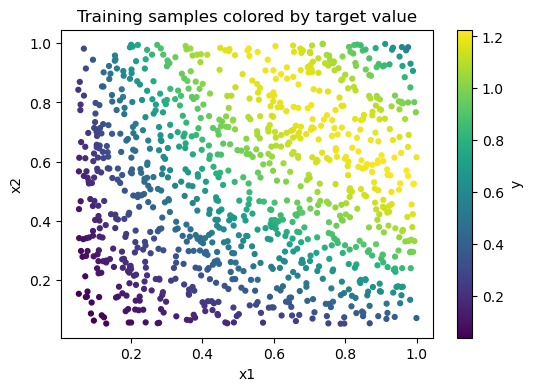

In [27]:
torch.manual_seed(42)

n_train = 1000
n_test = 300

x_train = 0.05 + 0.95 * torch.rand(n_train, 2)
x_test = 0.05 + 0.95 * torch.rand(n_test, 2)

def target_fn_interaction(x):
    x1 = x[:, 0:1]
    x2 = x[:, 1:2]
    y = torch.sin(3.0 * x1 * x2) + 0.2 * x1 + 0.1 * x2**2
    return y

y_train = target_fn_interaction(x_train)
y_test = target_fn_interaction(x_test)

plt.figure(figsize=(6, 4))
plt.scatter(x_train[:, 0].numpy(), x_train[:, 1].numpy(), c=y_train[:, 0].numpy(), s=12)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Training samples colored by target value")
plt.colorbar(label="y")
plt.show()

In [28]:
def train_regression_model(
    model,
    x_train,
    y_train,
    x_test,
    y_test,
    lr=1e-2,
    num_epochs=2500,
    print_every=250,
):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    train_losses = []
    test_losses = []

    for epoch in range(num_epochs):
        model.train()
        optimizer.zero_grad()

        y_pred = model(x_train)
        train_loss = loss_fn(y_pred, y_train)
        train_loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            y_test_pred = model(x_test)
            test_loss = loss_fn(y_test_pred, y_test)

        train_losses.append(train_loss.item())
        test_losses.append(test_loss.item())

        if epoch % print_every == 0:
            print(
                f"Epoch {epoch:4d} | "
                f"train loss = {train_loss.item():.6f} | "
                f"test loss = {test_loss.item():.6f}"
            )

    return train_losses, test_losses

In [29]:
def plot_predictions_vs_truth(model, x_test, y_test, title="Prediction vs truth"):
    model.eval()
    with torch.no_grad():
        y_pred = model(x_test)

    plt.figure(figsize=(6, 6))
    plt.scatter(y_test[:, 0].numpy(), y_pred[:, 0].numpy(), alpha=0.5, s=18)

    minv = min(y_test.min().item(), y_pred.min().item())
    maxv = max(y_test.max().item(), y_pred.max().item())
    plt.plot([minv, maxv], [minv, maxv], linestyle="--")

    plt.xlabel("True y")
    plt.ylabel("Predicted y")
    plt.title(title)
    plt.grid(True)
    plt.show()

In [30]:
def plot_loss_curves(train_losses, test_losses, title="Loss curves"):
    plt.figure(figsize=(7, 4))
    plt.plot(train_losses, label="train")
    plt.plot(test_losses, label="test")
    plt.xlabel("Epoch")
    plt.ylabel("MSE loss")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

In [31]:
model_shallow = KAN(
    in_count=2,
    out_count=1,
    hidden_layer_sizes=[],
    num_basis=12,
    x_min=0.0,
    x_max=1.0,
    gamma_scale=3.0,
    debug=False,
)

train_losses_shallow, test_losses_shallow = train_regression_model(
    model=model_shallow,
    x_train=x_train,
    y_train=y_train,
    x_test=x_test,
    y_test=y_test,
    lr=1e-2,
    num_epochs=2500,
    print_every=250,
)

Epoch    0 | train loss = 0.611043 | test loss = 0.448464
Epoch  250 | train loss = 0.013708 | test loss = 0.014768
Epoch  500 | train loss = 0.012966 | test loss = 0.014356
Epoch  750 | train loss = 0.012796 | test loss = 0.014301
Epoch 1000 | train loss = 0.012729 | test loss = 0.014312
Epoch 1250 | train loss = 0.012703 | test loss = 0.014337
Epoch 1500 | train loss = 0.012694 | test loss = 0.014358
Epoch 1750 | train loss = 0.012691 | test loss = 0.014371
Epoch 2000 | train loss = 0.012691 | test loss = 0.014378
Epoch 2250 | train loss = 0.012691 | test loss = 0.014381


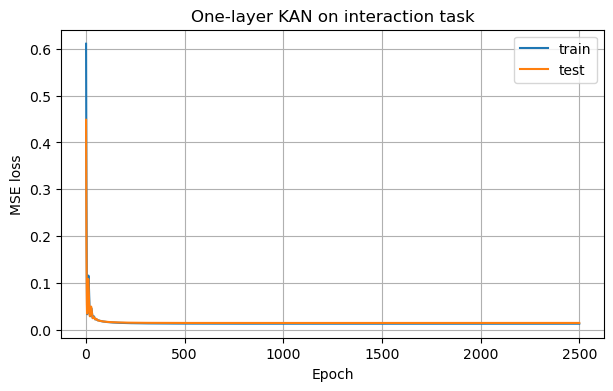

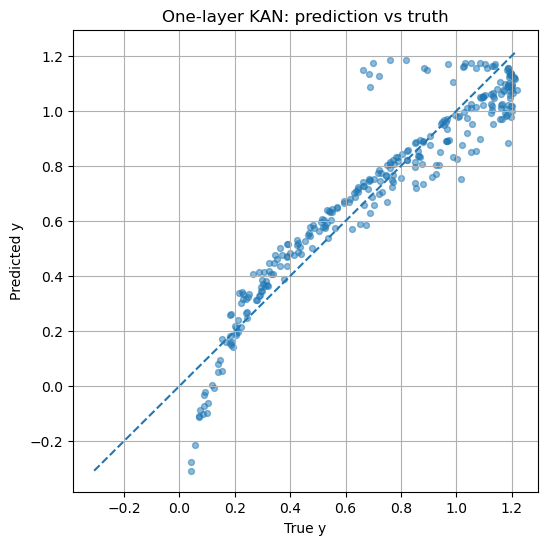

In [32]:
plot_loss_curves(
    train_losses_shallow,
    test_losses_shallow,
    title="One-layer KAN on interaction task"
)

plot_predictions_vs_truth(
    model_shallow,
    x_test,
    y_test,
    title="One-layer KAN: prediction vs truth"
)

### Shallow KAN on interaction regression: discussion

The predicted-vs-true plot shows that the shallow model captures the general trend, but the fit is not perfect. This is expected, since the target contains the interaction term $x_1x_2$, while a one-layer KAN is naturally better suited to additive structure across input coordinates.

Although the basis functions are strictly positive, the final output is not constrained to be positive, because the model combines them using coefficients that may be either positive or negative.

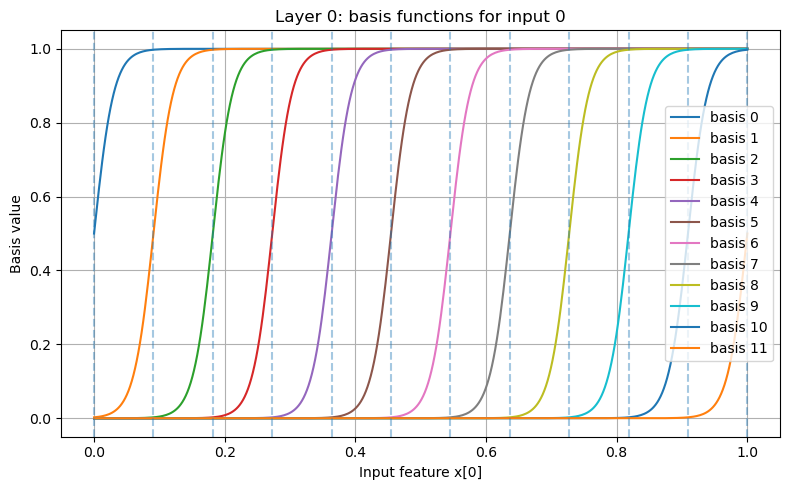

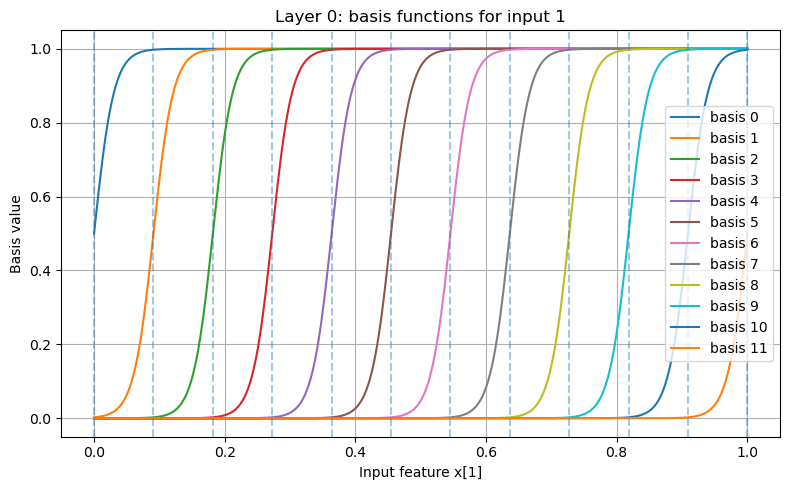

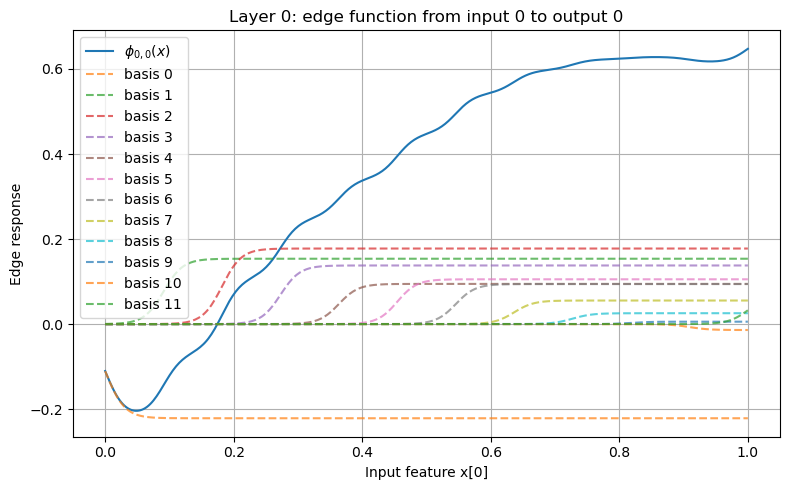

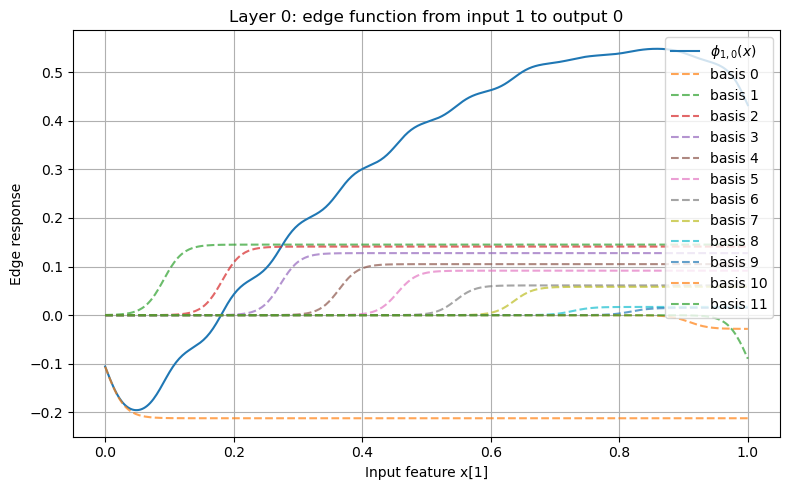

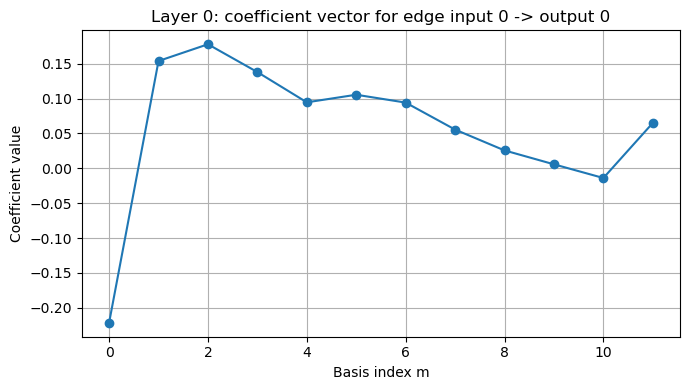

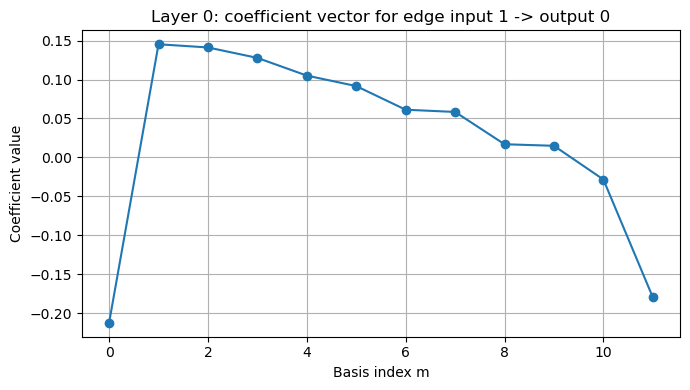

In [33]:
model_shallow.plot_basis_functions(layer_idx=0, in_idx=0, x_range=(0.0, 1.0))
model_shallow.plot_basis_functions(layer_idx=0, in_idx=1, x_range=(0.0, 1.0))

model_shallow.plot_edge_function(layer_idx=0, out_idx=0, in_idx=0, x_range=(0.0, 1.0), show_basis=True)
model_shallow.plot_edge_function(layer_idx=0, out_idx=0, in_idx=1, x_range=(0.0, 1.0), show_basis=True)

model_shallow.plot_coefficient_vector(layer_idx=0, out_idx=0, in_idx=0)
model_shallow.plot_coefficient_vector(layer_idx=0, out_idx=0, in_idx=1)

# One hidden layer

In [34]:
model_hidden = KAN(
    in_count=2,
    out_count=1,
    hidden_layer_sizes=[8],
    num_basis=12,
    x_min=-3.0,
    x_max=3.0,
    gamma_scale=3.0,
    debug=False,
)

train_losses_hidden, test_losses_hidden = train_regression_model(
    model=model_hidden,
    x_train=x_train,
    y_train=y_train,
    x_test=x_test,
    y_test=y_test,
    lr=1e-2,
    num_epochs=2500,
    print_every=250,
)

Epoch    0 | train loss = 0.852816 | test loss = 0.268680
Epoch  250 | train loss = 0.001309 | test loss = 0.001086
Epoch  500 | train loss = 0.000973 | test loss = 0.000807
Epoch  750 | train loss = 0.000633 | test loss = 0.000536
Epoch 1000 | train loss = 0.000438 | test loss = 0.000387
Epoch 1250 | train loss = 0.000353 | test loss = 0.000317
Epoch 1500 | train loss = 0.001193 | test loss = 0.000736
Epoch 1750 | train loss = 0.000227 | test loss = 0.000213
Epoch 2000 | train loss = 0.000153 | test loss = 0.000143
Epoch 2250 | train loss = 0.000095 | test loss = 0.000086


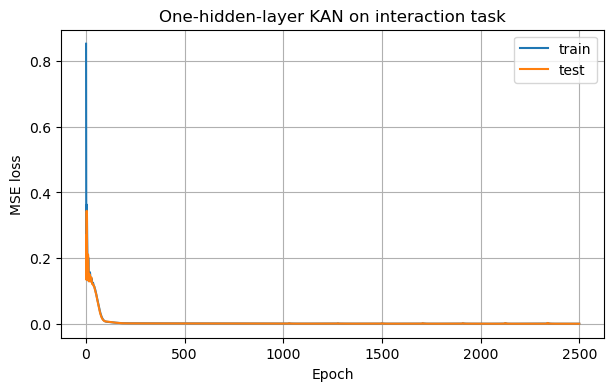

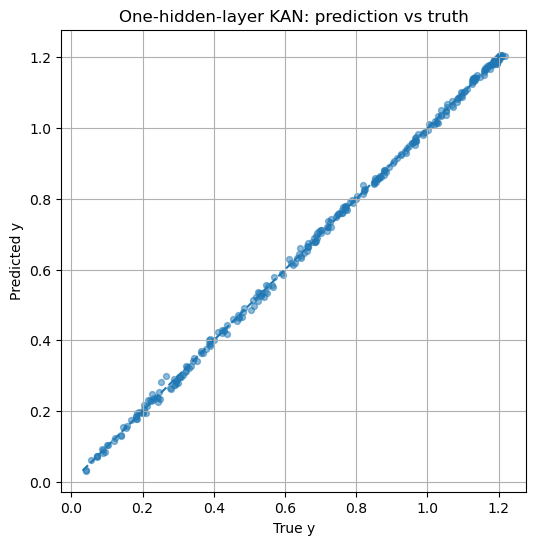

In [35]:
plot_loss_curves(
    train_losses_hidden,
    test_losses_hidden,
    title="One-hidden-layer KAN on interaction task"
)

plot_predictions_vs_truth(
    model_hidden,
    x_test,
    y_test,
    title="One-hidden-layer KAN: prediction vs truth"
)

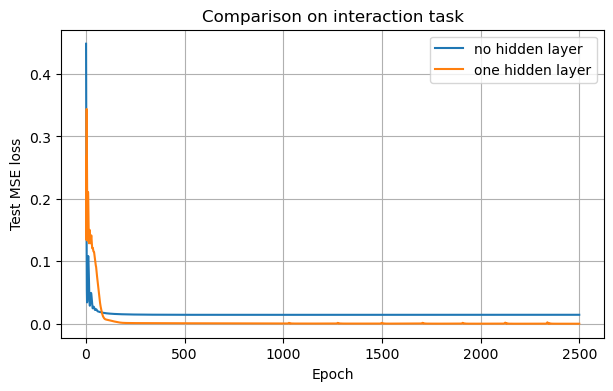

In [36]:
plt.figure(figsize=(7, 4))
plt.plot(test_losses_shallow, label="no hidden layer")
plt.plot(test_losses_hidden, label="one hidden layer")
plt.xlabel("Epoch")
plt.ylabel("Test MSE loss")
plt.title("Comparison on interaction task")
plt.legend()
plt.grid(True)
plt.show()

In [37]:
print(f"Final shallow test loss: {test_losses_shallow[-1]:.6f}")
print(f"Final hidden test loss:  {test_losses_hidden[-1]:.6f}")

Final shallow test loss: 0.014382
Final hidden test loss:  0.000069


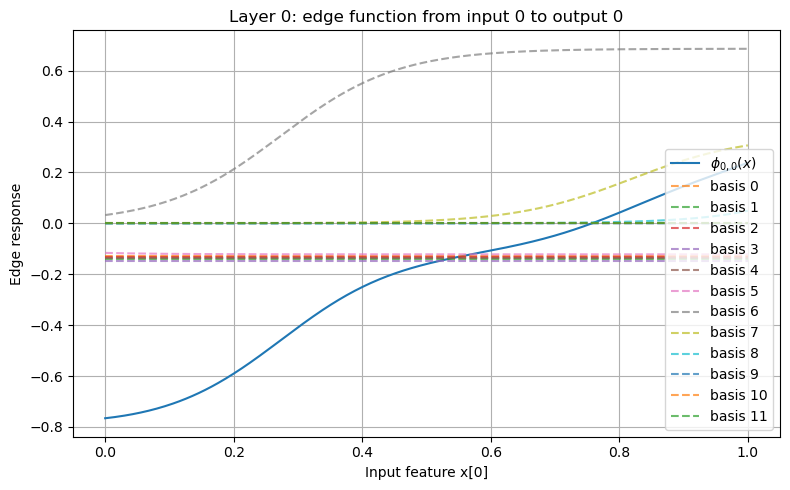

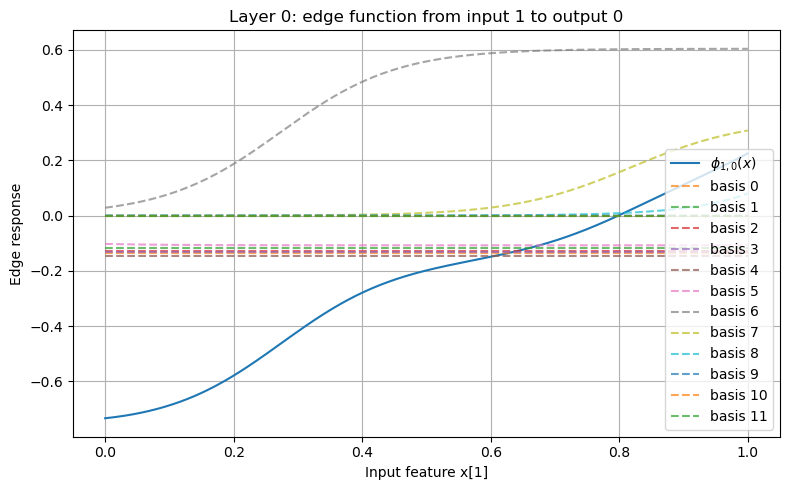

In [38]:
model_hidden.plot_edge_function(layer_idx=0, out_idx=0, in_idx=0, x_range=(0.0, 1.0), show_basis=True)
model_hidden.plot_edge_function(layer_idx=0, out_idx=0, in_idx=1, x_range=(0.0, 1.0), show_basis=True)

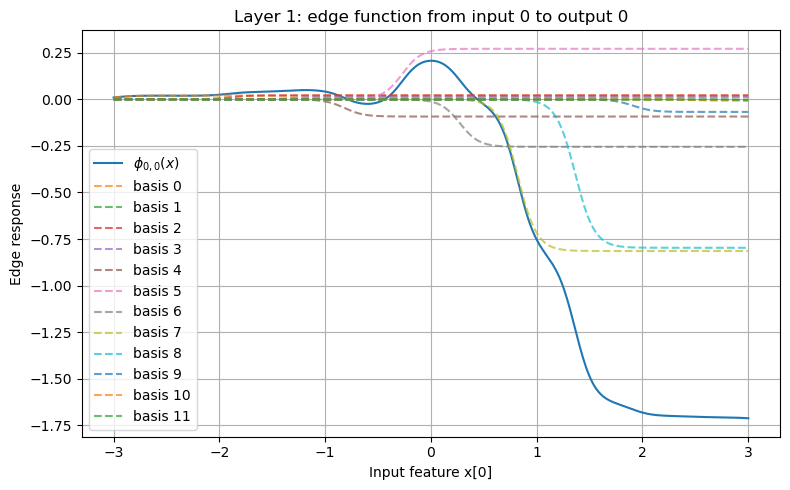

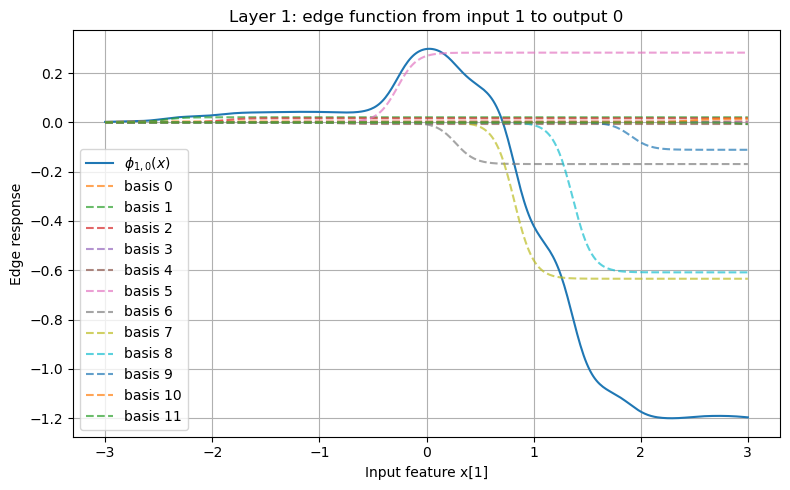

In [39]:
model_hidden.plot_edge_function(layer_idx=1, out_idx=0, in_idx=0, x_range=(-3.0, 3.0), show_basis=True)
model_hidden.plot_edge_function(layer_idx=1, out_idx=0, in_idx=1, x_range=(-3.0, 3.0), show_basis=True)

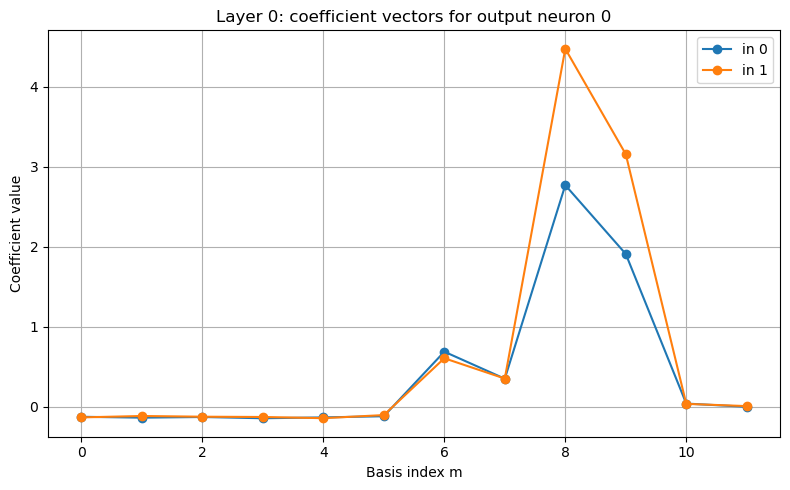

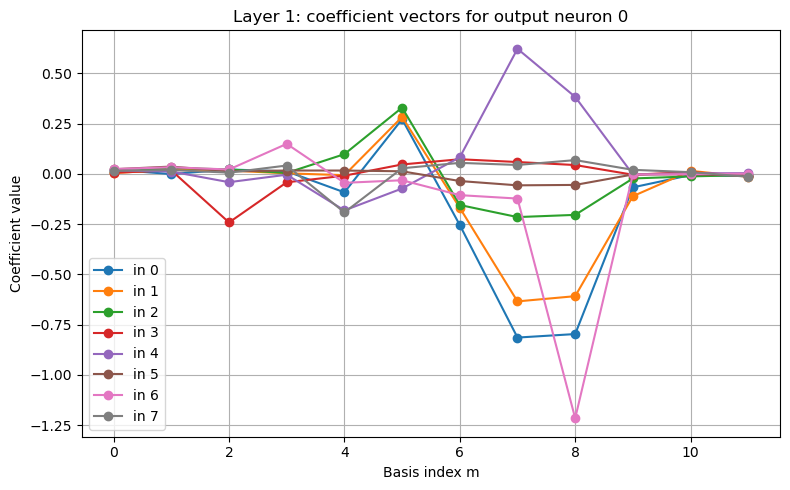

In [40]:
model_hidden.plot_all_coefficient_vectors(layer_idx=0, out_idx=0)
model_hidden.plot_all_coefficient_vectors(layer_idx=1, out_idx=0)

### One-hidden-layer KAN on interaction regression: discussion

Compared to the shallow model, the one-hidden-layer KAN fits the target much more accurately.  
This is expected, since the hidden layer increases the model’s ability to represent interactions between inputs.

Although several basis functions appear almost inactive, this is not necessarily a problem.  
In practice, the network often uses only a subset of the available basis functions strongly, while others make only small corrections or remain near zero because they are not needed in the active input region.

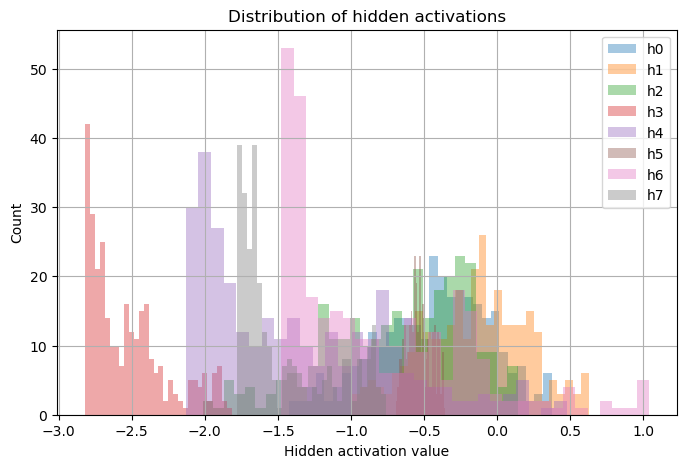

In [41]:
with torch.no_grad():
    layer_outputs = model_hidden.get_layer_outputs(x_test)

hidden_out = layer_outputs[0]  # output of first layer, input to second layer

plt.figure(figsize=(8, 5))
for i in range(hidden_out.shape[1]):
    plt.hist(hidden_out[:, i].numpy(), bins=30, alpha=0.4, label=f"h{i}")
plt.title("Distribution of hidden activations")
plt.xlabel("Hidden activation value")
plt.ylabel("Count")
plt.grid(True)
plt.legend()
plt.show()

# New experiments with affine transformation layers

### Test 1:
$$
f(x_1, x_2) = \exp(-x_1^2)\,(1 + x_2)^2
$$

In [68]:
torch.manual_seed(42)

n_train = 1000
n_test = 300

x_train = 0.05 + 0.95 * torch.rand(n_train, 2)
x_test = 0.05 + 0.95 * torch.rand(n_test, 2)

def target_fn_positive(x):
    x1 = x[:, 0:1]
    x2 = x[:, 1:2]
    return torch.exp(-x1**2) * (1 + x2)**2

y_train = target_fn(x_train)
y_test = target_fn(x_test)

In [69]:
torch.manual_seed(42)

model_std = KAN(
    in_count=2,
    out_count=2,
    hidden_layer_sizes=[],
    num_basis=12,
    x_min=0.0,
    x_max=1.0,
    gamma_scale=3.0,
    debug=False,
    layer_type="standard",
)

optimizer_std = optim.Adam(model_std.parameters(), lr=1e-2)
loss_fn = nn.MSELoss()
num_epochs = 2500

train_losses_std = []
test_losses_std = []

for epoch in range(num_epochs):
    model_std.train()
    optimizer_std.zero_grad()

    y_pred = model_std(x_train)
    loss = loss_fn(y_pred, y_train)
    loss.backward()
    optimizer_std.step()

    model_std.eval()
    with torch.no_grad():
        y_test_pred = model_std(x_test)
        test_loss = loss_fn(y_test_pred, y_test)

    train_losses_std.append(loss.item())
    test_losses_std.append(test_loss.item())

    if epoch % 250 == 0:
        print(f"[STD] Epoch {epoch:4d} | train loss = {loss.item():.6f} | test loss = {test_loss.item():.6f}")

[STD] Epoch    0 | train loss = 0.529681 | test loss = 0.442989
[STD] Epoch  250 | train loss = 0.000357 | test loss = 0.000349
[STD] Epoch  500 | train loss = 0.000202 | test loss = 0.000214
[STD] Epoch  750 | train loss = 0.000188 | test loss = 0.000199
[STD] Epoch 1000 | train loss = 0.000185 | test loss = 0.000194
[STD] Epoch 1250 | train loss = 0.000184 | test loss = 0.000192
[STD] Epoch 1500 | train loss = 0.000184 | test loss = 0.000192
[STD] Epoch 1750 | train loss = 0.000184 | test loss = 0.000192
[STD] Epoch 2000 | train loss = 0.000213 | test loss = 0.000193
[STD] Epoch 2250 | train loss = 0.000185 | test loss = 0.000192


In [70]:
torch.manual_seed(42)

model_aff = KAN(
    in_count=2,
    out_count=2,
    hidden_layer_sizes=[],
    num_basis=12,
    x_min=0.0,
    x_max=1.0,
    gamma_scale=3.0,
    debug=False,
    layer_type="affine",
    learn_affine=True,
)

optimizer_aff = optim.Adam(model_aff.parameters(), lr=1e-2)

train_losses_aff = []
test_losses_aff = []

for epoch in range(num_epochs):
    model_aff.train()
    optimizer_aff.zero_grad()

    y_pred = model_aff(x_train)
    loss = loss_fn(y_pred, y_train)
    loss.backward()
    optimizer_aff.step()

    model_aff.eval()
    with torch.no_grad():
        y_test_pred = model_aff(x_test)
        test_loss = loss_fn(y_test_pred, y_test)

    train_losses_aff.append(loss.item())
    test_losses_aff.append(test_loss.item())

    if epoch % 250 == 0:
        print(f"[AFF] Epoch {epoch:4d} | train loss = {loss.item():.6f} | test loss = {test_loss.item():.6f}")

[AFF] Epoch    0 | train loss = 0.527487 | test loss = 0.461377
[AFF] Epoch  250 | train loss = 0.000385 | test loss = 0.000345
[AFF] Epoch  500 | train loss = 0.000270 | test loss = 0.000265
[AFF] Epoch  750 | train loss = 0.000260 | test loss = 0.000267
[AFF] Epoch 1000 | train loss = 0.000258 | test loss = 0.000269
[AFF] Epoch 1250 | train loss = 0.000257 | test loss = 0.000270
[AFF] Epoch 1500 | train loss = 0.000255 | test loss = 0.000270
[AFF] Epoch 1750 | train loss = 0.000253 | test loss = 0.000268
[AFF] Epoch 2000 | train loss = 0.000251 | test loss = 0.000264
[AFF] Epoch 2250 | train loss = 0.000247 | test loss = 0.000255


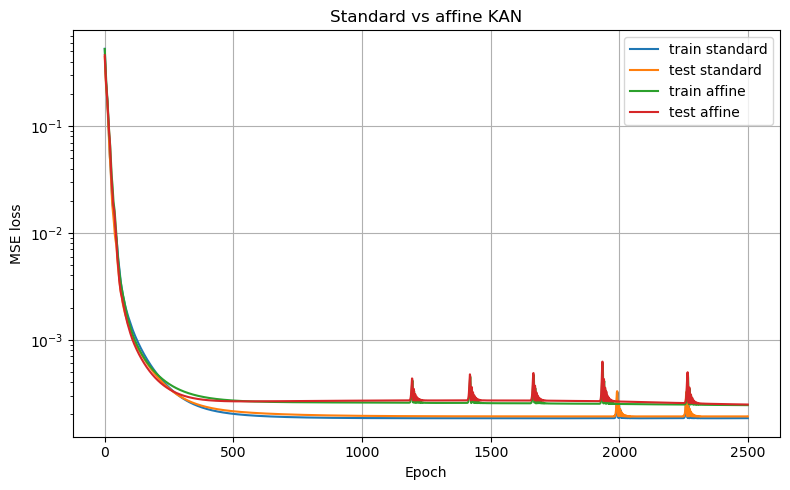

In [71]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses_std, label="train standard")
plt.plot(test_losses_std, label="test standard")
plt.plot(train_losses_aff, label="train affine")
plt.plot(test_losses_aff, label="test affine")
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Standard vs affine KAN")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [72]:
print("Final standard train loss:", train_losses_std[-1])
print("Final standard test loss: ", test_losses_std[-1])
print("Final affine train loss:  ", train_losses_aff[-1])
print("Final affine test loss:   ", test_losses_aff[-1])

Final standard train loss: 0.00018443187582306564
Final standard test loss:  0.0001917514018714428
Final affine train loss:   0.00024417604436166584
Final affine test loss:    0.0002474999928381294


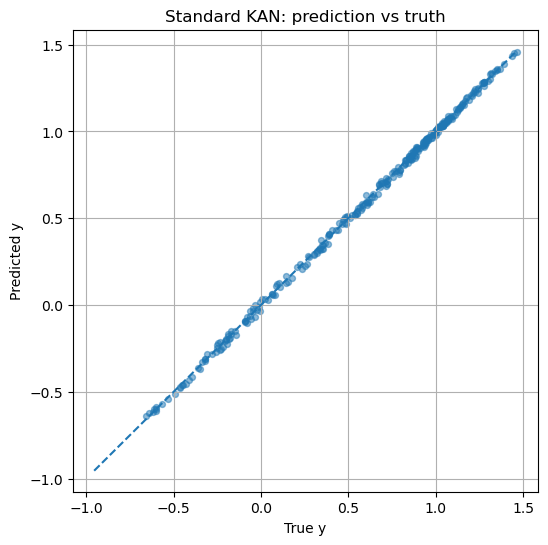

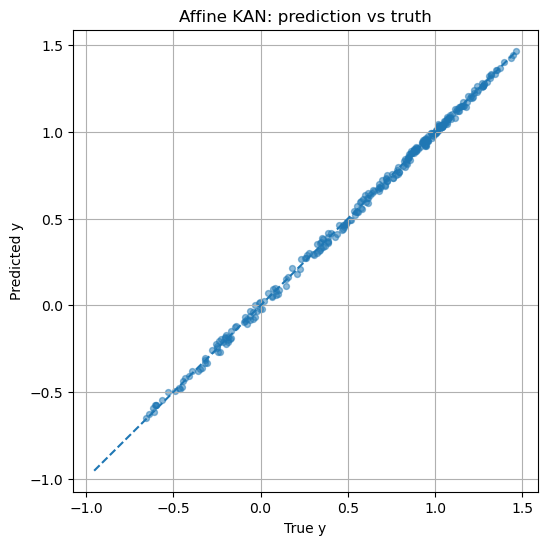

In [73]:
plot_predictions_vs_truth(
    model_std,
    x_test,
    y_test,
    title="Standard KAN: prediction vs truth"
)

plot_predictions_vs_truth(
    model_aff,
    x_test,
    y_test,
    title="Affine KAN: prediction vs truth"
)

In [74]:
for layer_idx, layer in enumerate(model_aff.layers):
    if hasattr(layer, "get_alpha") and hasattr(layer, "get_beta"):
        alpha = layer.get_alpha().detach().cpu()
        beta = layer.get_beta().detach().cpu()

        print(f"Layer {layer_idx}")
        print("alpha:", alpha.numpy())
        print("beta: ", beta.numpy())

Layer 0
alpha: [0.83283323 0.8927546 ]
beta:  [0.09084608 0.04026066]


In [75]:
def check_edge_positivity(model, layer_idx=0, x_range=None, resolution=400):
    layer = model.layers[layer_idx]

    if x_range is None:
        xmin, xmax = model.x_min, model.x_max
    else:
        xmin, xmax = x_range

    x = torch.linspace(xmin, xmax, resolution)

    num_negative = 0
    total = 0

    for out_idx in range(layer.out_count):
        for in_idx in range(layer.in_count):
            if hasattr(layer, "compute_basis_for_input_grid"):
                basis = layer.compute_basis_for_input_grid(in_idx, x)
            else:
                centers = layer.centers[in_idx]
                slopes = layer.slopes[in_idx]
                basis = 0.5 * (
                    1.0 + torch.tanh(
                        slopes.unsqueeze(0) * (x.unsqueeze(1) - centers.unsqueeze(0))
                    )
                )

            coeffs = layer.coeffs[out_idx, in_idx]
            phi = (basis * coeffs.unsqueeze(0)).sum(dim=1)

            total += 1
            if torch.any(phi < 0):
                num_negative += 1

    print(f"Layer {layer_idx}: {num_negative}/{total} edge functions go negative on the sampled grid.")

In [76]:
check_edge_positivity(model_std, layer_idx=0)
check_edge_positivity(model_aff, layer_idx=0)

Layer 0: 2/4 edge functions go negative on the sampled grid.
Layer 0: 3/4 edge functions go negative on the sampled grid.


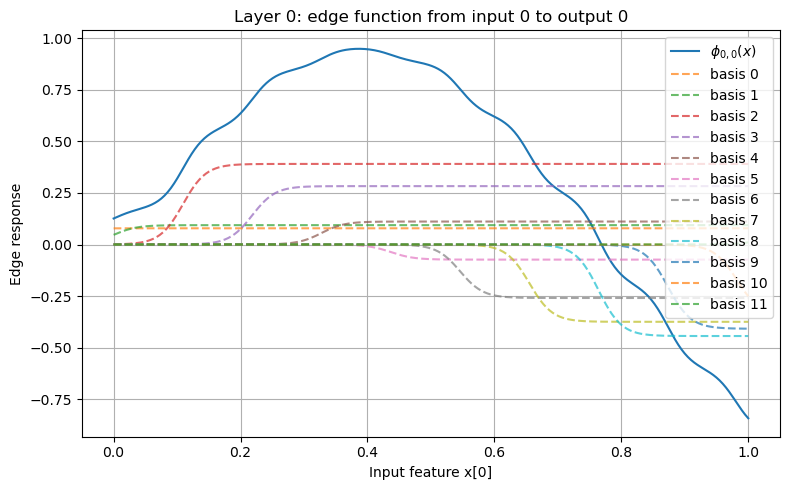

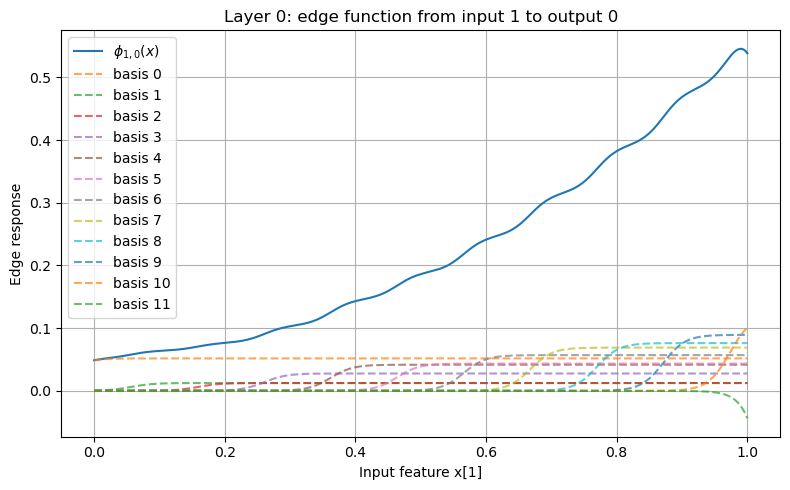

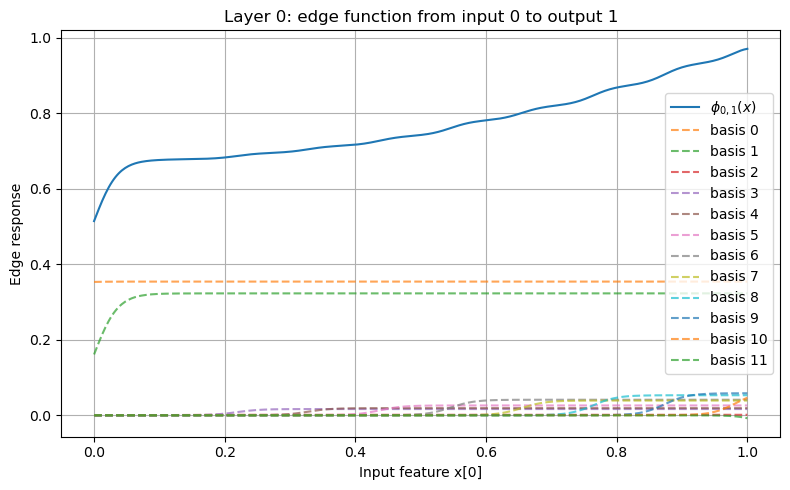

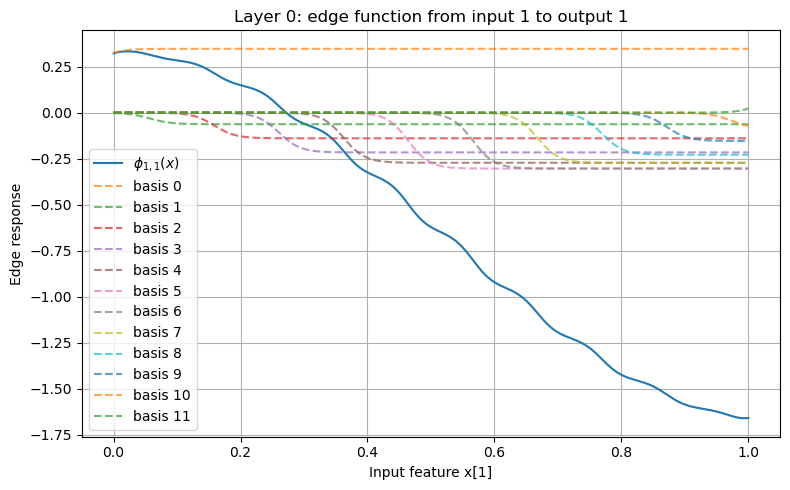

In [77]:
model_aff.plot_edge_function(layer_idx=0, out_idx=0, in_idx=0, x_range=(0.0, 1.0), show_basis=True)
model_aff.plot_edge_function(layer_idx=0, out_idx=0, in_idx=1, x_range=(0.0, 1.0), show_basis=True)
model_aff.plot_edge_function(layer_idx=0, out_idx=1, in_idx=0, x_range=(0.0, 1.0), show_basis=True)
model_aff.plot_edge_function(layer_idx=0, out_idx=1, in_idx=1, x_range=(0.0,    1.0), show_basis=True)

### Test 2: 
$$
f(x_1, x_2) = \exp\left(\sqrt{x_1^2 + x_2^2}\right)
$$

In [90]:
def target_fn_test2(x):
    x1 = x[:, 0:1]
    x2 = x[:, 1:2]
    return torch.exp(torch.sqrt(x1**2 + x2**2))

y_train = target_fn(x_train)
y_test = target_fn(x_test)

In [91]:
torch.manual_seed(42)

model_std = KAN(
    in_count=2,
    out_count=2,
    hidden_layer_sizes=[],
    num_basis=12,
    x_min=0.0,
    x_max=1.0,
    gamma_scale=3.0,
    debug=False,
    layer_type="standard",
)

optimizer_std = optim.Adam(model_std.parameters(), lr=1e-2)
loss_fn = nn.MSELoss()
num_epochs = 2500

train_losses_std = []
test_losses_std = []

for epoch in range(num_epochs):
    model_std.train()
    optimizer_std.zero_grad()

    y_pred = model_std(x_train)
    loss = loss_fn(y_pred, y_train)
    loss.backward()
    optimizer_std.step()

    model_std.eval()
    with torch.no_grad():
        y_test_pred = model_std(x_test)
        test_loss = loss_fn(y_test_pred, y_test)

    train_losses_std.append(loss.item())
    test_losses_std.append(test_loss.item())

    if epoch % 250 == 0:
        print(f"[STD] Epoch {epoch:4d} | train loss = {loss.item():.6f} | test loss = {test_loss.item():.6f}")

[STD] Epoch    0 | train loss = 0.529681 | test loss = 0.442989
[STD] Epoch  250 | train loss = 0.000357 | test loss = 0.000349
[STD] Epoch  500 | train loss = 0.000202 | test loss = 0.000214
[STD] Epoch  750 | train loss = 0.000188 | test loss = 0.000199
[STD] Epoch 1000 | train loss = 0.000185 | test loss = 0.000194
[STD] Epoch 1250 | train loss = 0.000184 | test loss = 0.000192
[STD] Epoch 1500 | train loss = 0.000184 | test loss = 0.000192
[STD] Epoch 1750 | train loss = 0.000184 | test loss = 0.000192
[STD] Epoch 2000 | train loss = 0.000213 | test loss = 0.000193
[STD] Epoch 2250 | train loss = 0.000185 | test loss = 0.000192


In [92]:
torch.manual_seed(42)

model_aff = KAN(
    in_count=2,
    out_count=2,
    hidden_layer_sizes=[],
    num_basis=12,
    x_min=0.0,
    x_max=1.0,
    gamma_scale=3.0,
    debug=False,
    layer_type="affine",
    learn_affine=True,
)

optimizer_aff = optim.Adam(model_aff.parameters(), lr=1e-2)

train_losses_aff = []
test_losses_aff = []

for epoch in range(num_epochs):
    model_aff.train()
    optimizer_aff.zero_grad()

    y_pred = model_aff(x_train)
    loss = loss_fn(y_pred, y_train)
    loss.backward()
    optimizer_aff.step()

    model_aff.eval()
    with torch.no_grad():
        y_test_pred = model_aff(x_test)
        test_loss = loss_fn(y_test_pred, y_test)

    train_losses_aff.append(loss.item())
    test_losses_aff.append(test_loss.item())

    if epoch % 250 == 0:
        print(f"[AFF] Epoch {epoch:4d} | train loss = {loss.item():.6f} | test loss = {test_loss.item():.6f}")

[AFF] Epoch    0 | train loss = 0.527487 | test loss = 0.461377
[AFF] Epoch  250 | train loss = 0.000385 | test loss = 0.000345
[AFF] Epoch  500 | train loss = 0.000270 | test loss = 0.000265
[AFF] Epoch  750 | train loss = 0.000260 | test loss = 0.000267
[AFF] Epoch 1000 | train loss = 0.000258 | test loss = 0.000269
[AFF] Epoch 1250 | train loss = 0.000257 | test loss = 0.000270
[AFF] Epoch 1500 | train loss = 0.000255 | test loss = 0.000270
[AFF] Epoch 1750 | train loss = 0.000253 | test loss = 0.000268
[AFF] Epoch 2000 | train loss = 0.000251 | test loss = 0.000264
[AFF] Epoch 2250 | train loss = 0.000247 | test loss = 0.000255


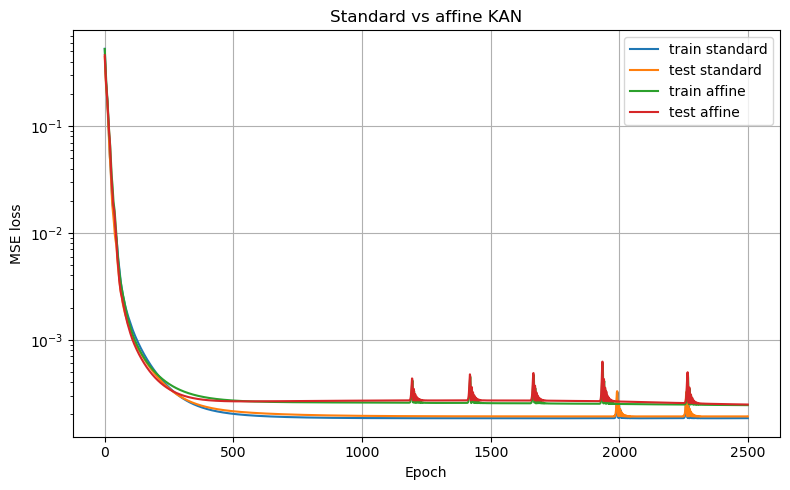

In [93]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses_std, label="train standard")
plt.plot(test_losses_std, label="test standard")
plt.plot(train_losses_aff, label="train affine")
plt.plot(test_losses_aff, label="test affine")
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Standard vs affine KAN")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

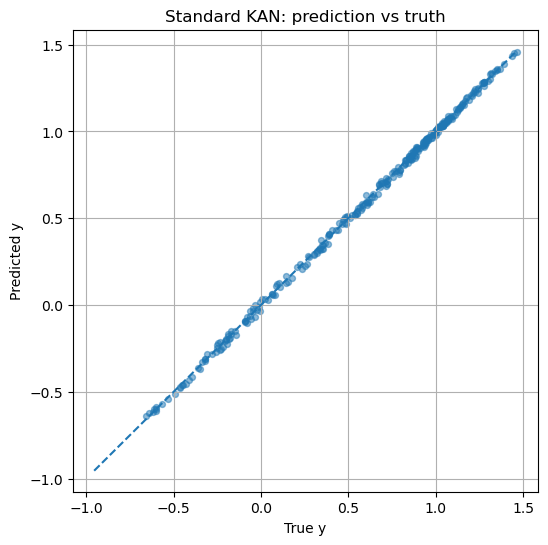

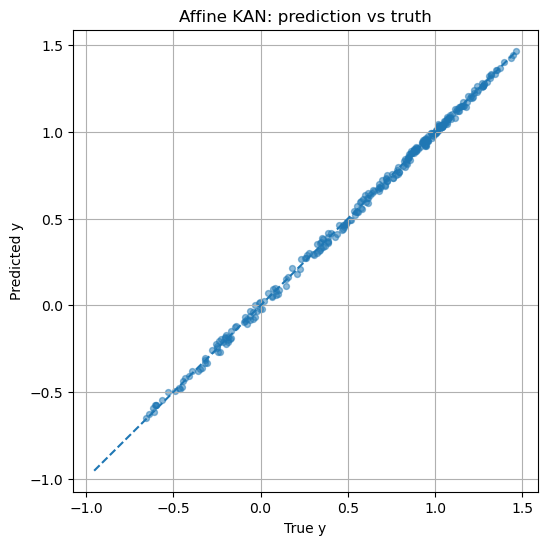

In [94]:
plot_predictions_vs_truth(
    model_std,
    x_test,
    y_test,
    title="Standard KAN: prediction vs truth"
)

plot_predictions_vs_truth(
    model_aff,
    x_test,
    y_test,
    title="Affine KAN: prediction vs truth"
)

In [95]:
check_edge_positivity(model_std, layer_idx=0)
check_edge_positivity(model_aff, layer_idx=0)

Layer 0: 2/4 edge functions go negative on the sampled grid.
Layer 0: 3/4 edge functions go negative on the sampled grid.


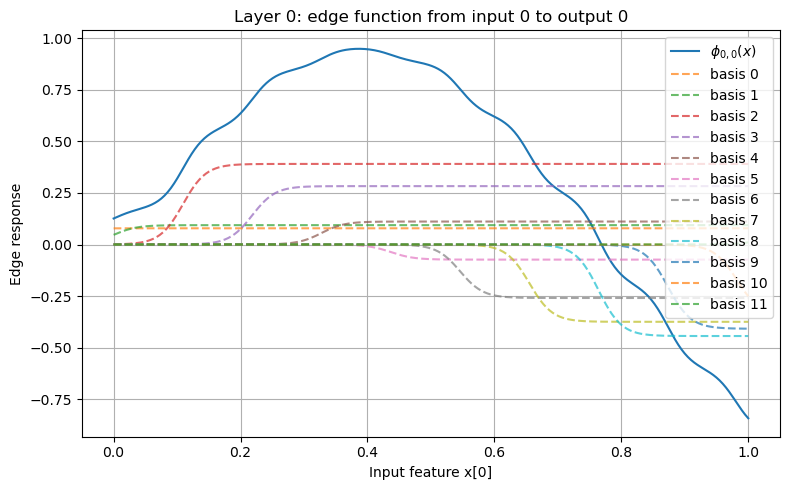

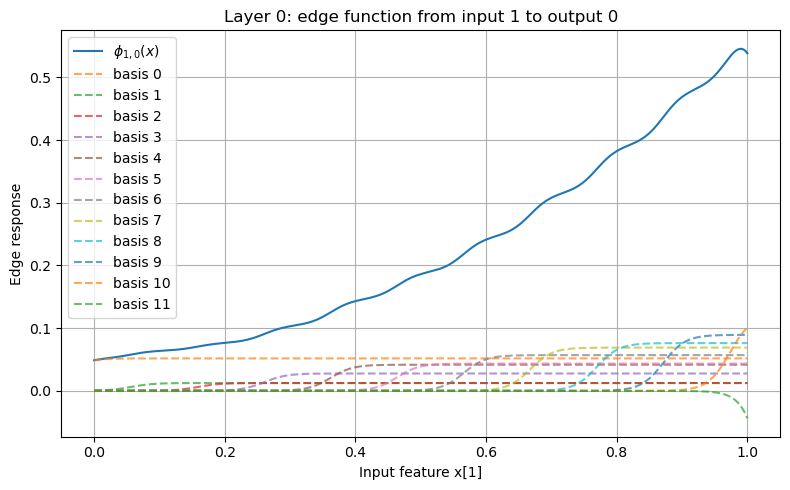

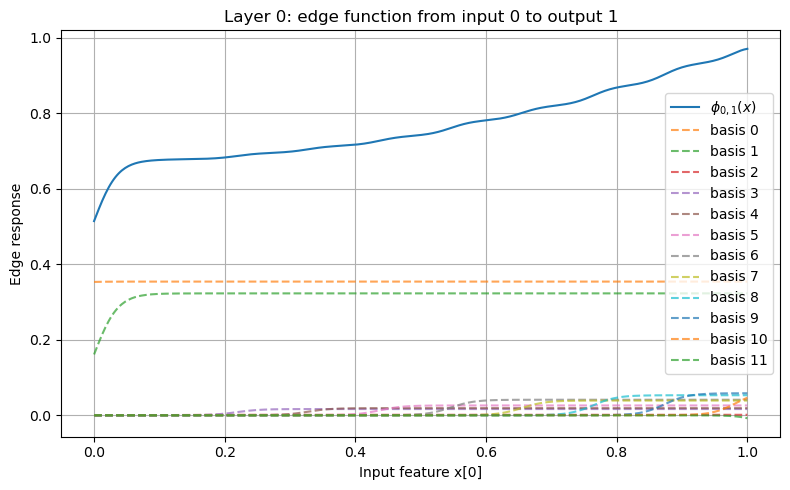

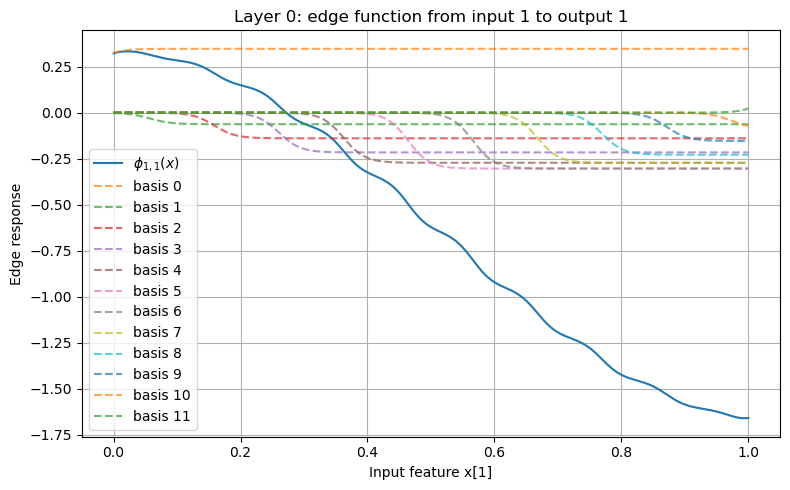

In [96]:
model_aff.plot_edge_function(layer_idx=0, out_idx=0, in_idx=0, x_range=(0.0, 1.0), show_basis=True)
model_aff.plot_edge_function(layer_idx=0, out_idx=0, in_idx=1, x_range=(0.0, 1.0), show_basis=True)
model_aff.plot_edge_function(layer_idx=0, out_idx=1, in_idx=0, x_range=(0.0, 1.0), show_basis=True)
model_aff.plot_edge_function(layer_idx=0, out_idx=1, in_idx=1, x_range=(0.0,    1.0), show_basis=True)

### Test 3:
$$
f(x_1, x_2) = \log(1 + x_1^2) + \sqrt{1 + x_2^2}
$$

In [104]:
def target_fn_test3(x):
    x1 = x[:, 0:1]
    x2 = x[:, 1:2]
    return torch.log(1 + x1**2) + torch.sqrt(1 + x2**2)

In [105]:
torch.manual_seed(42)

model_std = KAN(
    in_count=2,
    out_count=2,
    hidden_layer_sizes=[],
    num_basis=12,
    x_min=0.0,
    x_max=1.0,
    gamma_scale=3.0,
    debug=False,
    layer_type="standard",
)

optimizer_std = optim.Adam(model_std.parameters(), lr=1e-2)
loss_fn = nn.MSELoss()
num_epochs = 2500

train_losses_std = []
test_losses_std = []

for epoch in range(num_epochs):
    model_std.train()
    optimizer_std.zero_grad()

    y_pred = model_std(x_train)
    loss = loss_fn(y_pred, y_train)
    loss.backward()
    optimizer_std.step()

    model_std.eval()
    with torch.no_grad():
        y_test_pred = model_std(x_test)
        test_loss = loss_fn(y_test_pred, y_test)

    train_losses_std.append(loss.item())
    test_losses_std.append(test_loss.item())

    if epoch % 250 == 0:
        print(f"[STD] Epoch {epoch:4d} | train loss = {loss.item():.6f} | test loss = {test_loss.item():.6f}")

[STD] Epoch    0 | train loss = 0.529681 | test loss = 0.442989
[STD] Epoch  250 | train loss = 0.000357 | test loss = 0.000349
[STD] Epoch  500 | train loss = 0.000202 | test loss = 0.000214
[STD] Epoch  750 | train loss = 0.000188 | test loss = 0.000199
[STD] Epoch 1000 | train loss = 0.000185 | test loss = 0.000194
[STD] Epoch 1250 | train loss = 0.000184 | test loss = 0.000192
[STD] Epoch 1500 | train loss = 0.000184 | test loss = 0.000192
[STD] Epoch 1750 | train loss = 0.000184 | test loss = 0.000192
[STD] Epoch 2000 | train loss = 0.000213 | test loss = 0.000193
[STD] Epoch 2250 | train loss = 0.000185 | test loss = 0.000192


In [106]:
torch.manual_seed(42)

model_aff = KAN(
    in_count=2,
    out_count=2,
    hidden_layer_sizes=[],
    num_basis=12,
    x_min=0.0,
    x_max=1.0,
    gamma_scale=3.0,
    debug=False,
    layer_type="affine",
    learn_affine=True,
)

optimizer_aff = optim.Adam(model_aff.parameters(), lr=1e-2)

train_losses_aff = []
test_losses_aff = []

for epoch in range(num_epochs):
    model_aff.train()
    optimizer_aff.zero_grad()

    y_pred = model_aff(x_train)
    loss = loss_fn(y_pred, y_train)
    loss.backward()
    optimizer_aff.step()

    model_aff.eval()
    with torch.no_grad():
        y_test_pred = model_aff(x_test)
        test_loss = loss_fn(y_test_pred, y_test)

    train_losses_aff.append(loss.item())
    test_losses_aff.append(test_loss.item())

    if epoch % 250 == 0:
        print(f"[AFF] Epoch {epoch:4d} | train loss = {loss.item():.6f} | test loss = {test_loss.item():.6f}")

[AFF] Epoch    0 | train loss = 0.527487 | test loss = 0.461377
[AFF] Epoch  250 | train loss = 0.000385 | test loss = 0.000345
[AFF] Epoch  500 | train loss = 0.000270 | test loss = 0.000265
[AFF] Epoch  750 | train loss = 0.000260 | test loss = 0.000267
[AFF] Epoch 1000 | train loss = 0.000258 | test loss = 0.000269
[AFF] Epoch 1250 | train loss = 0.000257 | test loss = 0.000270
[AFF] Epoch 1500 | train loss = 0.000255 | test loss = 0.000270
[AFF] Epoch 1750 | train loss = 0.000253 | test loss = 0.000268
[AFF] Epoch 2000 | train loss = 0.000251 | test loss = 0.000264
[AFF] Epoch 2250 | train loss = 0.000247 | test loss = 0.000255


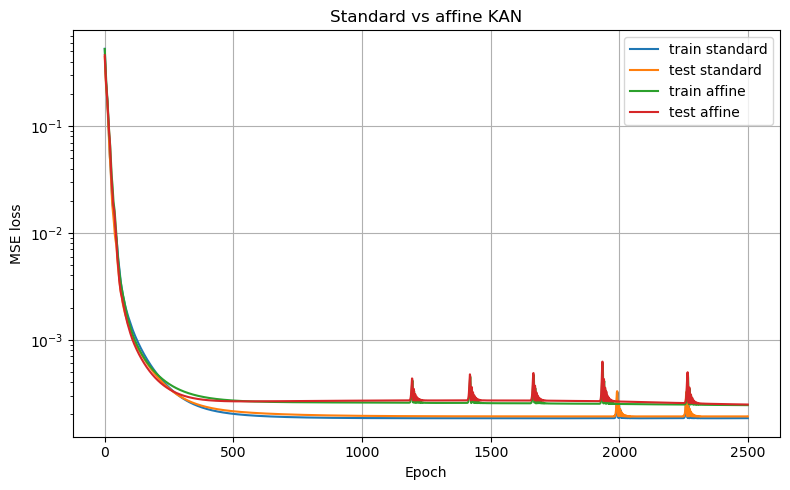

In [107]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses_std, label="train standard")
plt.plot(test_losses_std, label="test standard")
plt.plot(train_losses_aff, label="train affine")
plt.plot(test_losses_aff, label="test affine")
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Standard vs affine KAN")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

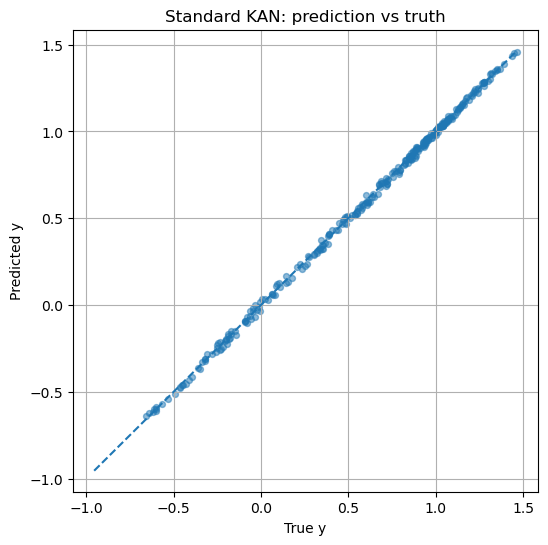

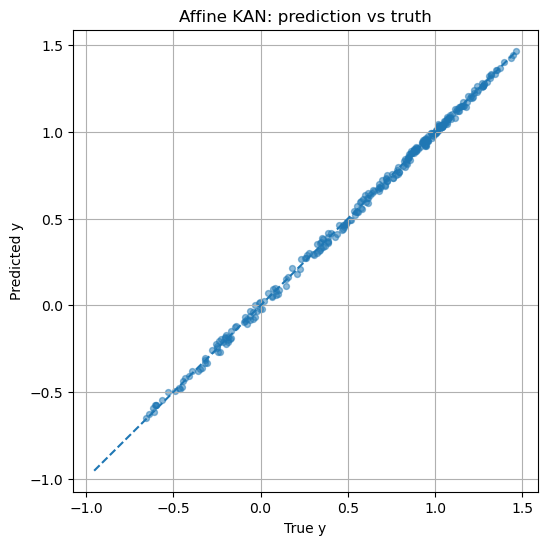

In [108]:
plot_predictions_vs_truth(
    model_std,
    x_test,
    y_test,
    title="Standard KAN: prediction vs truth"
)

plot_predictions_vs_truth(
    model_aff,
    x_test,
    y_test,
    title="Affine KAN: prediction vs truth"
)

In [109]:
check_edge_positivity(model_std, layer_idx=0)
check_edge_positivity(model_aff, layer_idx=0)

Layer 0: 2/4 edge functions go negative on the sampled grid.
Layer 0: 3/4 edge functions go negative on the sampled grid.


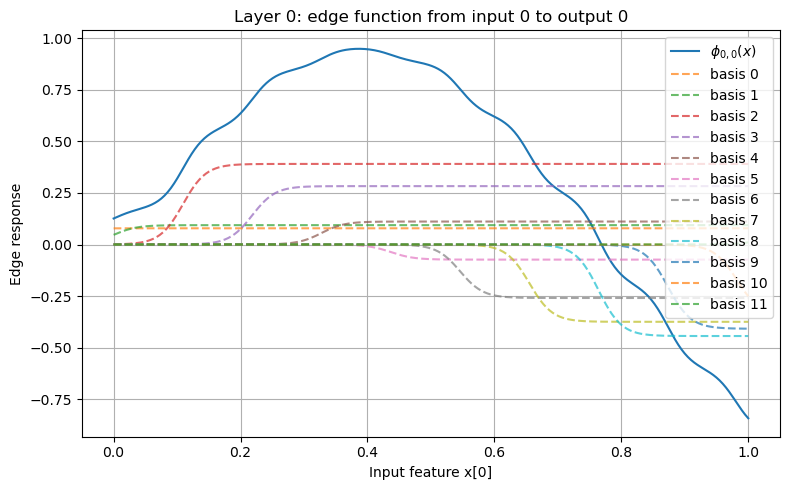

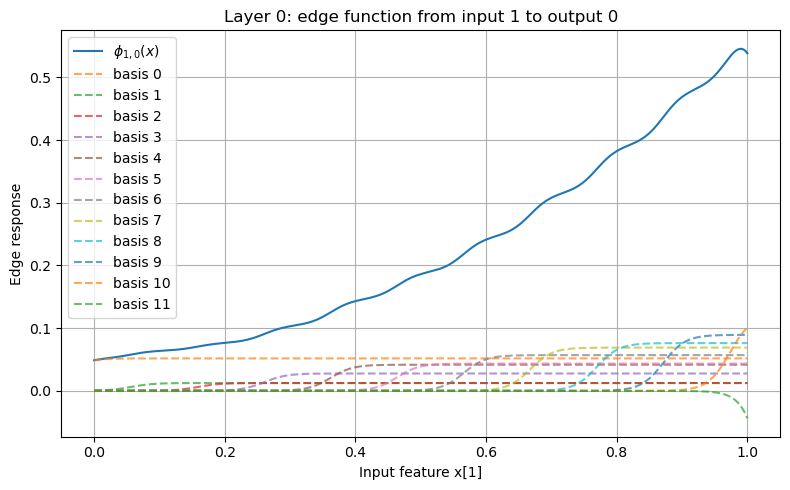

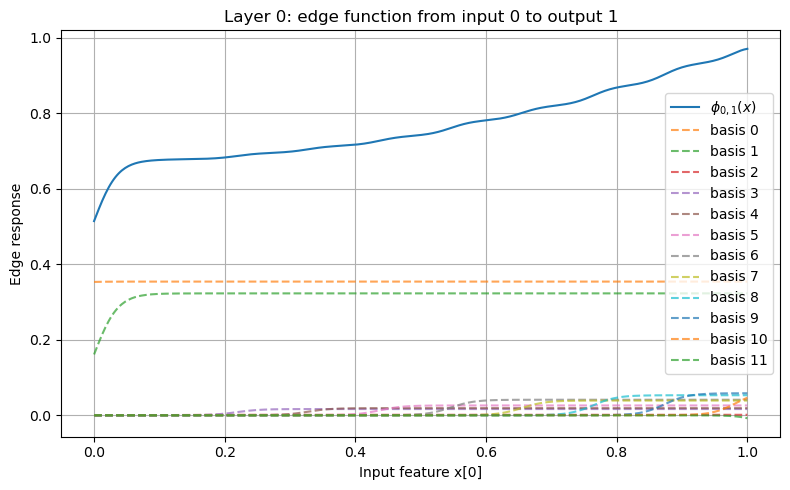

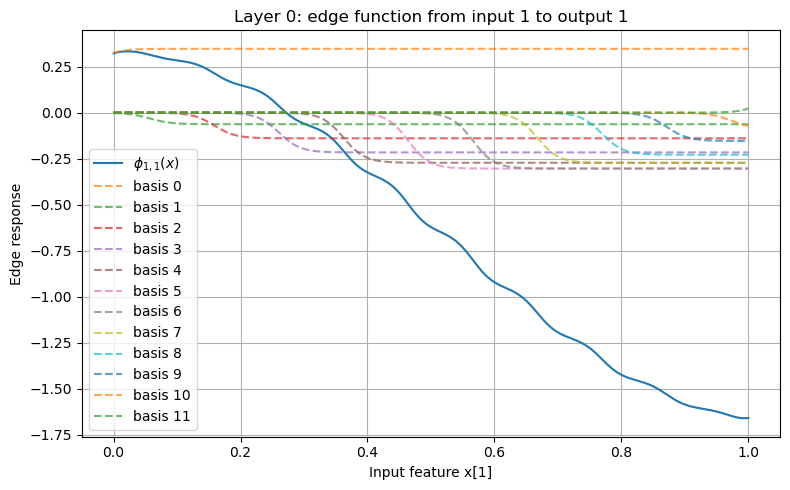

In [110]:
model_aff.plot_edge_function(layer_idx=0, out_idx=0, in_idx=0, x_range=(0.0, 1.0), show_basis=True)
model_aff.plot_edge_function(layer_idx=0, out_idx=0, in_idx=1, x_range=(0.0, 1.0), show_basis=True)
model_aff.plot_edge_function(layer_idx=0, out_idx=1, in_idx=0, x_range=(0.0, 1.0), show_basis=True)
model_aff.plot_edge_function(layer_idx=0, out_idx=1, in_idx=1, x_range=(0.0,    1.0), show_basis=True)

## Now let's play with photonics!

In [171]:
mat_path = "activation_KAN_fit_B_Sofija_extend_positive_basisKAN.mat"

b_coef, input_power, peakout_data, set_detuning = kan.load_photonic_activation_data(mat_path)

selected_indices = kan.select_equidistant_basis_indices(
    total_basis=b_coef.shape[0],
    num_selected=12,
)
#selected_indices = np.arange(12)

b_coef_selected = b_coef[selected_indices]

print("Selected indices:", selected_indices)
print("Selected detunings:", set_detuning[selected_indices])
print("Selected b_coef shape:", b_coef_selected.shape)

Selected indices: [ 0  3  6  9 12 15 18 21 24 27 30 33]
Selected detunings: tensor([-5.0000e+10, -8.0000e+10, -1.1000e+11, -1.4000e+11, -1.7000e+11,
        -2.0000e+11, -2.3000e+11, -2.6000e+11, -2.9000e+11, -3.2000e+11,
        -3.5000e+11, -3.8000e+11])
Selected b_coef shape: torch.Size([12, 8])


In [172]:
model = KAN(
    in_count=2,
    out_count=1,
    hidden_layer_sizes=[],
    layer_type="photonic",
    b_coef_selected=b_coef_selected,
    x_min=float(0.0),
    x_max=float(1.0),
    dropout_prob=0.0,
    normalize_basis=False,
    check_input_range=True,
    debug=False,
)

In [173]:
x = torch.rand(32, 2) * float(1.0)

y = model(x)

print("y shape:", y.shape)
y, stats = model.inspect_forward_range(x)
model.get_layer_outputs(x)

y shape: torch.Size([32, 1])
Final output:
  shape: (32, 1)
  min:   -0.07120535522699356
  max:   0.06284166872501373

Layer 0:
  input min:  0.015504121780395508
  input max:  0.9988759756088257
  basis min:  0.0003232363087590784
  basis max:  5.741643905639648
  output min: -0.07120535522699356
  output max: 0.06284166872501373



[tensor([[ 0.0173],
         [-0.0053],
         [-0.0433],
         [-0.0489],
         [-0.0652],
         [-0.0360],
         [-0.0410],
         [ 0.0053],
         [-0.0034],
         [-0.0510],
         [-0.0493],
         [-0.0495],
         [ 0.0233],
         [-0.0298],
         [ 0.0006],
         [-0.0056],
         [ 0.0221],
         [-0.0712],
         [-0.0382],
         [-0.0557],
         [-0.0422],
         [-0.0097],
         [ 0.0231],
         [-0.0601],
         [-0.0138],
         [-0.0437],
         [-0.0534],
         [ 0.0191],
         [-0.0084],
         [ 0.0628],
         [ 0.0344],
         [-0.0251]])]

In [174]:
for name, param in model.named_parameters():
    print(name, param.shape, param.requires_grad)

layers.0.coeffs torch.Size([1, 2, 12]) True


In [175]:
for name, buffer in model.named_buffers():
    print(name, buffer.shape)

layers.0.b_coef torch.Size([12, 8])


## First test

In [176]:
torch.manual_seed(42)

n_train = 1000
n_test = 300

x_min_test = 0.05
x_max_test = 10.0

x_train = x_min_test + x_max_test * torch.rand(n_train, 2)
x_test = x_min_test + x_max_test * torch.rand(n_test, 2)

def target_fn(x):
    x1 = x[:, 0:1]
    x2 = x[:, 1:2]

    x1n = x1 / x_max_test
    x2n = x2 / x_max_test

    y1 = torch.sin(4.0 * x1n) + 0.5 * x2n**2
    y2 = 0.3 * x1n**2 + torch.cos(3.0 * x2n)

    return torch.cat([y1, y2], dim=1)

y_train = target_fn(x_train)
y_test = target_fn(x_test)

In [177]:
model = KAN(
    in_count=2,
    out_count=2,
    hidden_layer_sizes=[],
    layer_type="photonic",
    b_coef_selected=b_coef_selected,
    x_min=float(input_power.min()),
    x_max=float(input_power.max()),
    dropout_prob=0.0,
    normalize_basis=False,
    check_input_range=True,
    debug=False,
)

In [178]:
optimizer = optim.Adam(model.parameters(), lr=1e-2)
loss_fn = nn.MSELoss()

num_epochs = 2500
train_losses = []
test_losses = []

for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()

    y_pred = model(x_train)
    loss = loss_fn(y_pred, y_train)
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        y_test_pred = model(x_test)
        test_loss = loss_fn(y_test_pred, y_test)

    train_losses.append(loss.item())
    test_losses.append(test_loss.item())

    if epoch % 250 == 0:
        print(
            f"Epoch {epoch:4d} | "
            f"train loss = {loss.item():.6f} | "
            f"test loss = {test_loss.item():.6f}"
        )

Epoch    0 | train loss = 0.479149 | test loss = 1.151984
Epoch  250 | train loss = 0.002247 | test loss = 0.001566
Epoch  500 | train loss = 0.001332 | test loss = 0.000777
Epoch  750 | train loss = 0.000929 | test loss = 0.000489
Epoch 1000 | train loss = 0.000703 | test loss = 0.000369
Epoch 1250 | train loss = 0.000575 | test loss = 0.000323
Epoch 1500 | train loss = 0.004334 | test loss = 0.007564
Epoch 1750 | train loss = 0.000438 | test loss = 0.000283
Epoch 2000 | train loss = 0.000400 | test loss = 0.000270
Epoch 2250 | train loss = 0.020578 | test loss = 0.009584


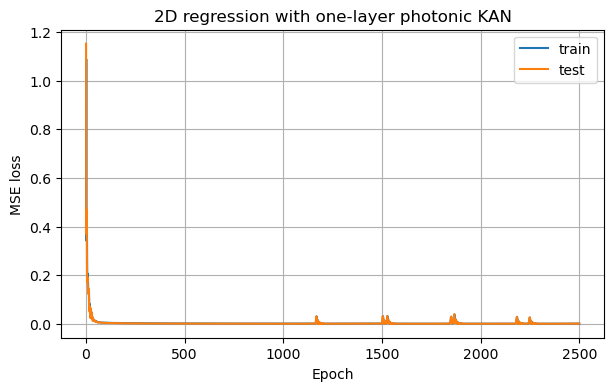

In [179]:
plt.figure(figsize=(7, 4))
plt.plot(train_losses, label="train")
plt.plot(test_losses, label="test")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("2D regression with one-layer photonic KAN")
plt.legend()
plt.grid(True)
plt.show()

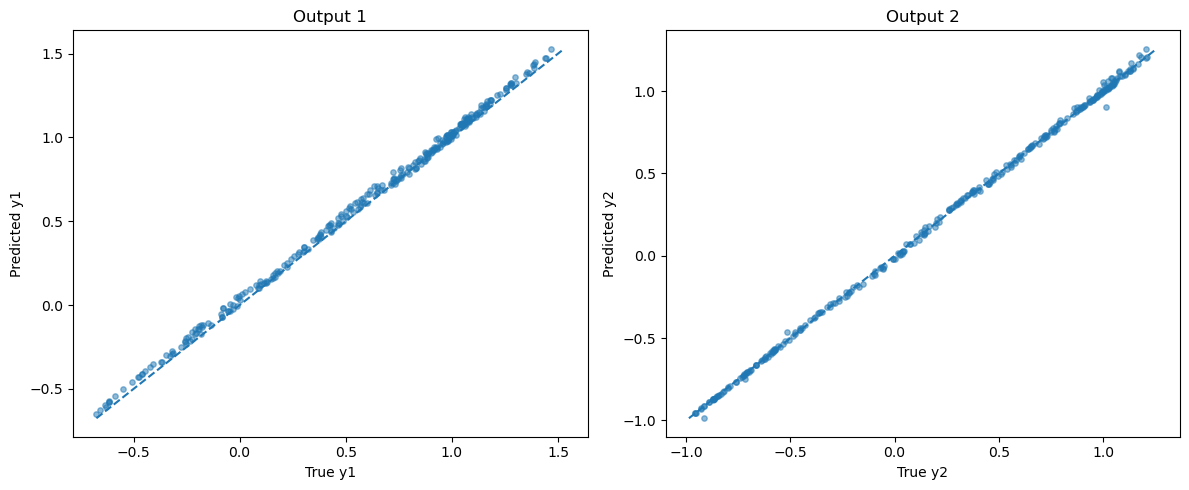

In [180]:
model.eval()
with torch.no_grad():
    y_pred_test = model(x_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for j in range(2):
    axes[j].scatter(y_test[:, j].numpy(), y_pred_test[:, j].numpy(), alpha=0.5, s=15)
    minv = min(y_test[:, j].min().item(), y_pred_test[:, j].min().item())
    maxv = max(y_test[:, j].max().item(), y_pred_test[:, j].max().item())
    axes[j].plot([minv, maxv], [minv, maxv], linestyle="--")
    axes[j].set_xlabel(f"True y{j+1}")
    axes[j].set_ylabel(f"Predicted y{j+1}")
    axes[j].set_title(f"Output {j+1}")

plt.tight_layout()
plt.show()

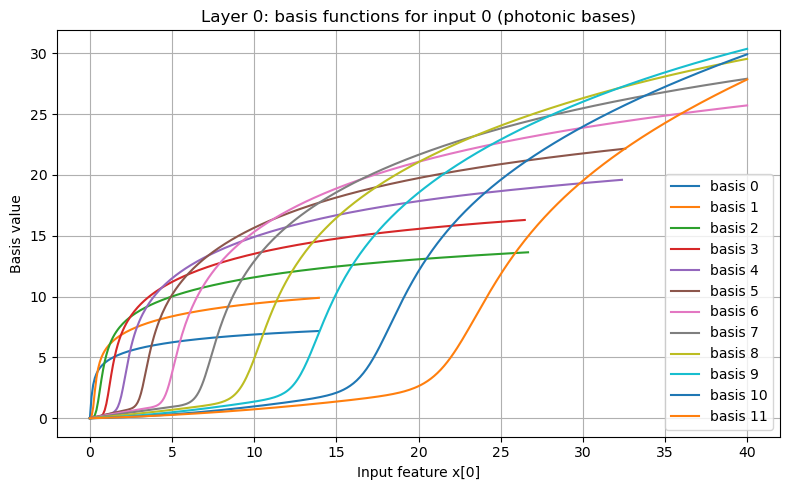

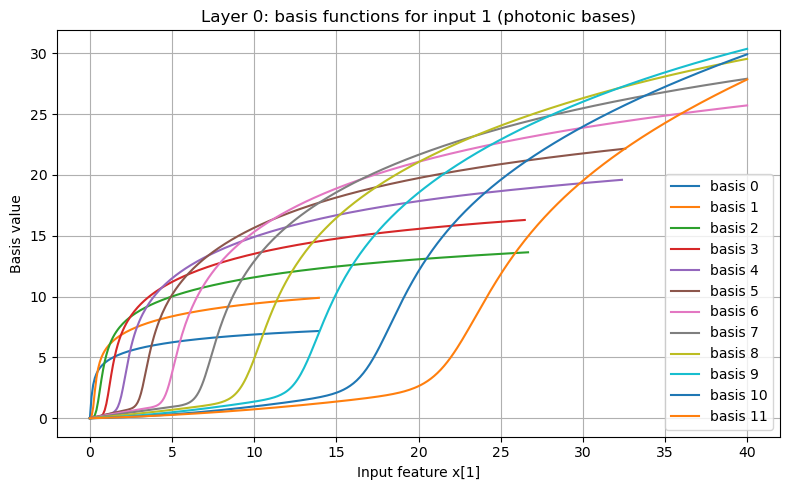

basis shape: torch.Size([400, 12])
basis finite: False
phi finite: False
First non-finite phi at:
  index: 140
  x: 14.035087585449219
  phi: inf
First non-finite basis at:
  x index: 140
  basis index: 0
  x: 14.035087585449219
  basis value: inf


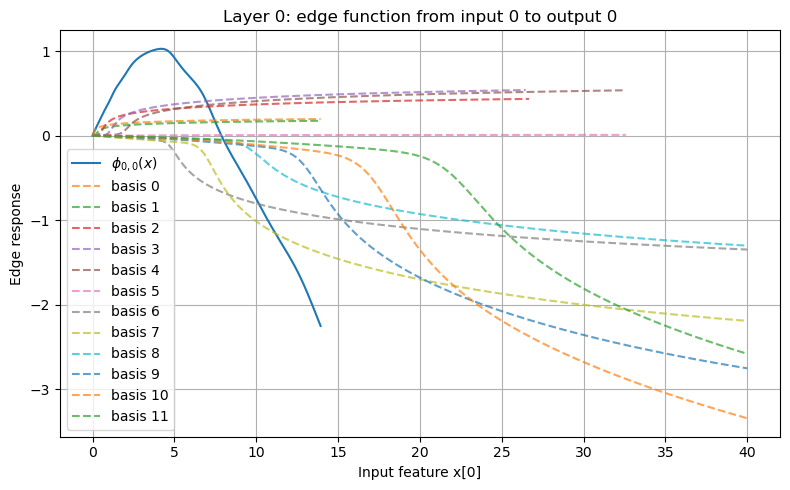

basis shape: torch.Size([400, 12])
basis finite: False
phi finite: False
First non-finite phi at:
  index: 140
  x: 14.035087585449219
  phi: nan
First non-finite basis at:
  x index: 140
  basis index: 0
  x: 14.035087585449219
  basis value: inf


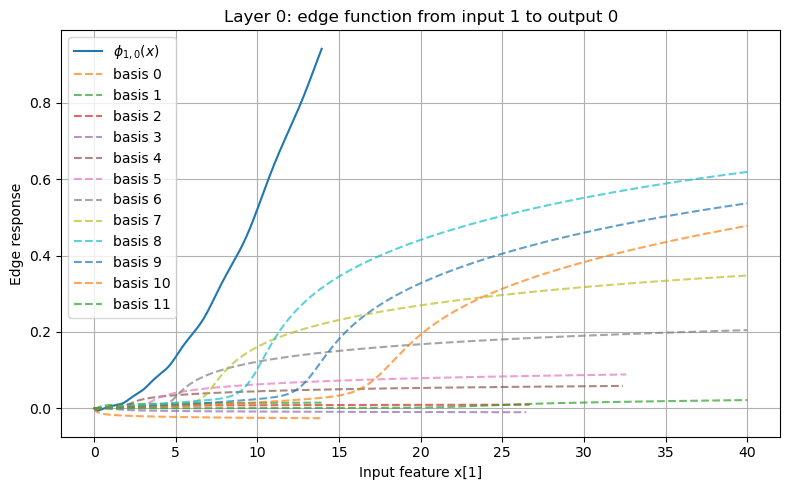

basis shape: torch.Size([400, 12])
basis finite: False
phi finite: False
First non-finite phi at:
  index: 140
  x: 14.035087585449219
  phi: nan
First non-finite basis at:
  x index: 140
  basis index: 0
  x: 14.035087585449219
  basis value: inf


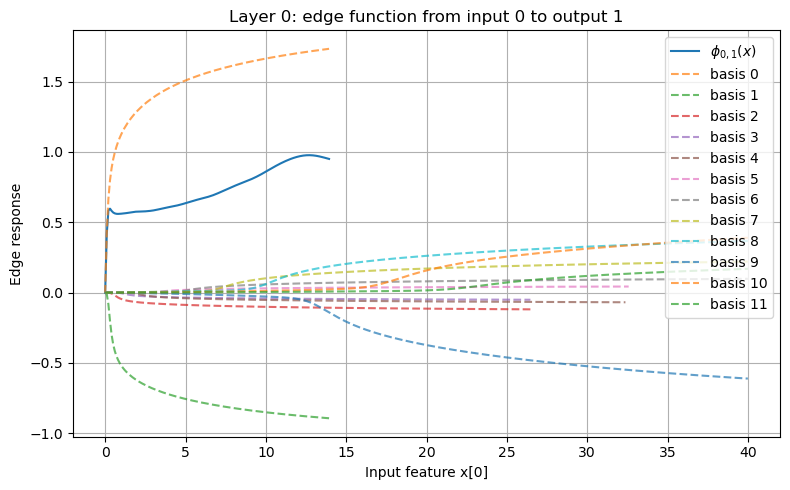

basis shape: torch.Size([400, 12])
basis finite: False
phi finite: False
First non-finite phi at:
  index: 140
  x: 14.035087585449219
  phi: nan
First non-finite basis at:
  x index: 140
  basis index: 0
  x: 14.035087585449219
  basis value: inf


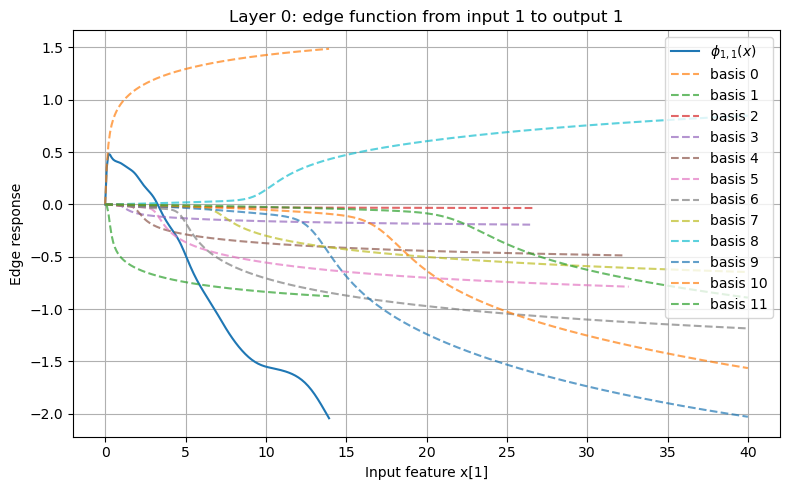

In [182]:
model.plot_basis_functions(layer_idx=0, in_idx=0, x_range=(0.0, 40.0))
model.plot_basis_functions(layer_idx=0, in_idx=1, x_range=(0.0, 40.0))

model.plot_edge_function(layer_idx=0, out_idx=0, in_idx=0, x_range=(0.0, 40.0), show_basis=True)
model.plot_edge_function(layer_idx=0, out_idx=0, in_idx=1, x_range=(0.0, 40.0), show_basis=True)
model.plot_edge_function(layer_idx=0, out_idx=1, in_idx=0, x_range=(0.0, 40.0), show_basis=True)
model.plot_edge_function(layer_idx=0, out_idx=1, in_idx=1, x_range=(0.0, 40.0), show_basis=True)

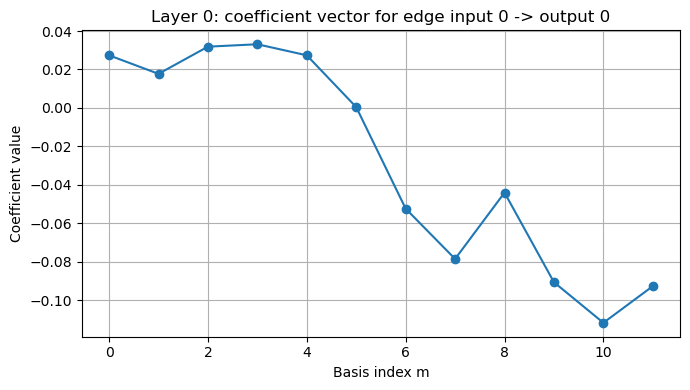

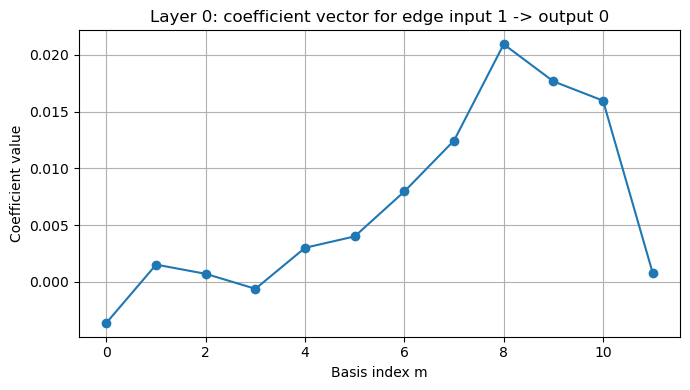

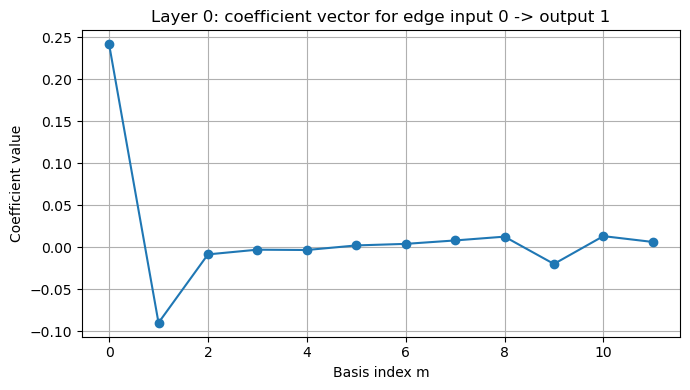

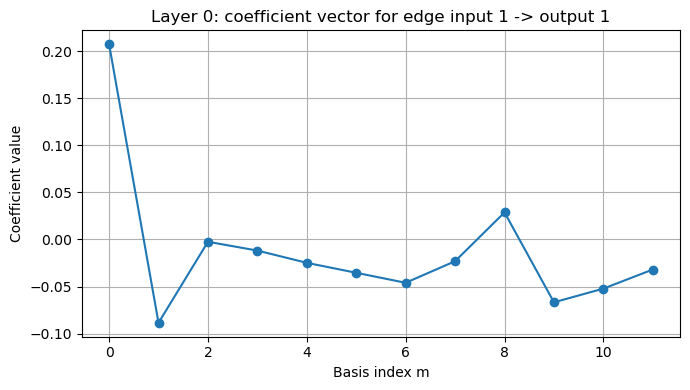

In [183]:
model.plot_coefficient_vector(layer_idx=0, out_idx=0, in_idx=0)
model.plot_coefficient_vector(layer_idx=0, out_idx=0, in_idx=1)
model.plot_coefficient_vector(layer_idx=0, out_idx=1, in_idx=0)
model.plot_coefficient_vector(layer_idx=0, out_idx=1, in_idx=1)

In [92]:
def plot_output_surface(model, out_idx=0, x1_range=(0.0, 1.0), x2_range=(0.0, 1.0), resolution=80):
    model.eval()

    x1 = torch.linspace(x1_range[0], x1_range[1], resolution)
    x2 = torch.linspace(x2_range[0], x2_range[1], resolution)

    X1, X2 = torch.meshgrid(x1, x2, indexing="ij")
    grid = torch.stack([X1.reshape(-1), X2.reshape(-1)], dim=1)

    with torch.no_grad():
        Y = model(grid)[:, out_idx].reshape(resolution, resolution)

    plt.figure(figsize=(6, 5))
    plt.contourf(X1.numpy(), X2.numpy(), Y.numpy(), levels=30)
    plt.colorbar()
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(f"Model output surface for y{out_idx+1}")
    plt.tight_layout()
    plt.show()

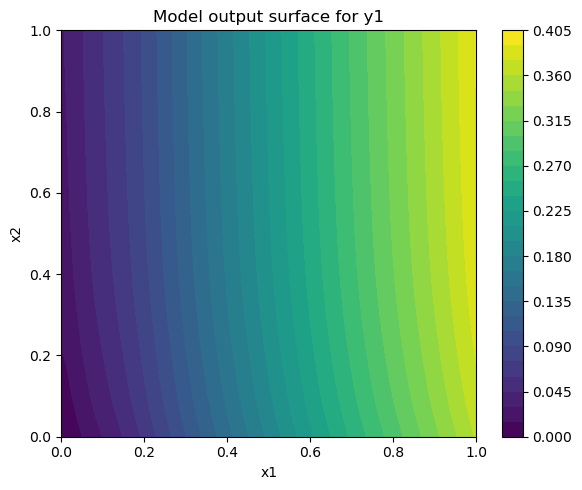

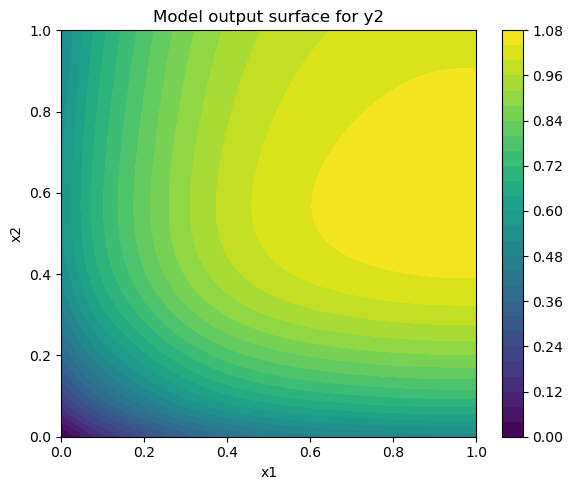

In [93]:
plot_output_surface(model, out_idx=0, x1_range=(0.0, 1.0), x2_range=(0.0, 1.0))
plot_output_surface(model, out_idx=1, x1_range=(0.0, 1.0), x2_range=(0.0, 1.0))

## Second test --> with clamp, so not reproducible

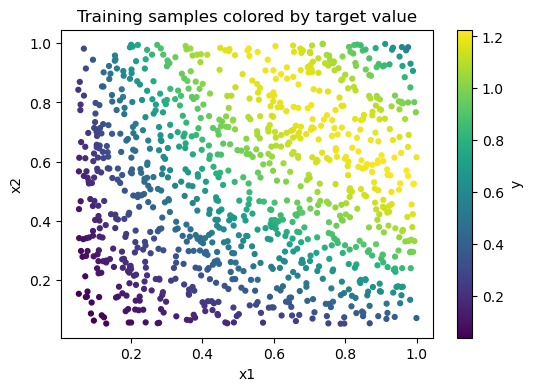

In [29]:
torch.manual_seed(42)

# -------------------------
# Data
# -------------------------

n_train = 1000
n_test = 300

x_train = 0.05 + 0.95 * torch.rand(n_train, 2)
x_test = 0.05 + 0.95 * torch.rand(n_test, 2)

def target_fn_interaction(x):
    x1 = x[:, 0:1]
    x2 = x[:, 1:2]
    y = torch.sin(3.0 * x1 * x2) + 0.2 * x1 + 0.1 * x2**2
    return y

y_train = target_fn_interaction(x_train)
y_test = target_fn_interaction(x_test)

plt.figure(figsize=(6, 4))
plt.scatter(
    x_train[:, 0].numpy(),
    x_train[:, 1].numpy(),
    c=y_train[:, 0].numpy(),
    s=12,
)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Training samples colored by target value")
plt.colorbar(label="y")
plt.show()

In [30]:
mat_path = "activation_KAN_fit_B_Sofija_extend_positive_basisKAN.mat"

b_coef, input_power, peakout_data, set_detuning = kan.load_photonic_activation_data(mat_path)

selected_indices = kan.select_equidistant_basis_indices(
    total_basis=b_coef.shape[0],
    num_selected=12,
)

b_coef_selected = b_coef[selected_indices]

print("Selected basis indices:", selected_indices)
print("Selected detunings:", set_detuning[selected_indices])
print("Selected b_coef shape:", b_coef_selected.shape)
print("input_power range:", float(input_power.min()), float(input_power.max()))

Selected basis indices: [ 0  3  6  9 12 15 18 21 24 27 30 33]
Selected detunings: tensor([-5.0000e+10, -8.0000e+10, -1.1000e+11, -1.4000e+11, -1.7000e+11,
        -2.0000e+11, -2.3000e+11, -2.6000e+11, -2.9000e+11, -3.2000e+11,
        -3.5000e+11, -3.8000e+11])
Selected b_coef shape: torch.Size([12, 8])
input_power range: 0.0 60.0


In [31]:
model_hidden_photonic = KAN(
    in_count=2,
    out_count=1,
    hidden_layer_sizes=[8],
    layer_type="photonic",
    b_coef_selected=b_coef_selected,
    x_min=float(input_power.min()),
    x_max=float(input_power.max()),
    clamp_input=True,          # temporary: clamp before photonic formula
    normalize_basis=True,
    debug=False,
)

In [32]:
def print_hidden_layer_range(model, x, label=""):
    model.eval()

    with torch.no_grad():
        h = x

        # Output of first layer, before entering second layer
        h1 = model.layers[0](h)

        print(f"\nHidden output range {label}")
        print(f"  shape: {tuple(h1.shape)}")
        print(f"  min:   {h1.min().item():.6f}")
        print(f"  max:   {h1.max().item():.6f}")
        print(f"  mean:  {h1.mean().item():.6f}")
        print(f"  std:   {h1.std().item():.6f}")
        print(f"  num negative: {(h1 < 0).sum().item()} / {h1.numel()}")
        print(f"  num above input_power max: {(h1 > float(input_power.max())).sum().item()} / {h1.numel()}")

        h1_clamped = torch.clamp(
            h1,
            min=float(input_power.min()),
            max=float(input_power.max()),
        )

        print("After temporary clamp before second photonic layer:")
        print(f"  min:   {h1_clamped.min().item():.6f}")
        print(f"  max:   {h1_clamped.max().item():.6f}")

    return h1

In [33]:
h1_initial = print_hidden_layer_range(
    model_hidden_photonic,
    x_train,
    label="before training",
)


Hidden output range before training
  shape: (1000, 8)
  min:   -0.003080
  max:   0.003297
  mean:  0.000237
  std:   0.001388
  num negative: 3341 / 8000
  num above input_power max: 0 / 8000
After temporary clamp before second photonic layer:
  min:   0.000000
  max:   0.003297


In [34]:
def train_regression_model_with_hidden_tracking(
    model,
    x_train,
    y_train,
    x_test,
    y_test,
    lr=1e-2,
    num_epochs=2500,
    print_every=250,
):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    train_losses = []
    test_losses = []

    for epoch in range(num_epochs):
        model.train()
        optimizer.zero_grad()

        y_pred = model(x_train)
        train_loss = loss_fn(y_pred, y_train)

        if torch.isnan(train_loss) or torch.isinf(train_loss):
            print(f"Stopping at epoch {epoch}: invalid train loss.")
            print("y_pred has nan:", torch.isnan(y_pred).any().item())
            print("y_pred has inf:", torch.isinf(y_pred).any().item())
            break

        train_loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            y_test_pred = model(x_test)
            test_loss = loss_fn(y_test_pred, y_test)

        train_losses.append(train_loss.item())
        test_losses.append(test_loss.item())

        if epoch % print_every == 0:
            print(
                f"Epoch {epoch:4d} | "
                f"train loss = {train_loss.item():.6f} | "
                f"test loss = {test_loss.item():.6f}"
            )

            print_hidden_layer_range(
                model,
                x_train,
                label=f"at epoch {epoch}",
            )

    return train_losses, test_losses

In [35]:
train_losses_hidden, test_losses_hidden = train_regression_model_with_hidden_tracking(
    model=model_hidden_photonic,
    x_train=x_train,
    y_train=y_train,
    x_test=x_test,
    y_test=y_test,
    lr=1e-2,
    num_epochs=2500,
    print_every=250,
)

Epoch    0 | train loss = 0.618590 | test loss = 0.643944

Hidden output range at epoch 0
  shape: (1000, 8)
  min:   -0.005436
  max:   0.009167
  mean:  0.001071
  std:   0.003555
  num negative: 4004 / 8000
  num above input_power max: 0 / 8000
After temporary clamp before second photonic layer:
  min:   0.000000
  max:   0.009167
Epoch  250 | train loss = 0.023580 | test loss = 0.024564

Hidden output range at epoch 250
  shape: (1000, 8)
  min:   -0.035063
  max:   0.730034
  mean:  0.200739
  std:   0.235395
  num negative: 4000 / 8000
  num above input_power max: 0 / 8000
After temporary clamp before second photonic layer:
  min:   0.000000
  max:   0.730034
Epoch  500 | train loss = 0.020571 | test loss = 0.021890

Hidden output range at epoch 500
  shape: (1000, 8)
  min:   -0.035063
  max:   0.704708
  mean:  0.197927
  std:   0.232247
  num negative: 4000 / 8000
  num above input_power max: 0 / 8000
After temporary clamp before second photonic layer:
  min:   0.000000
  max:

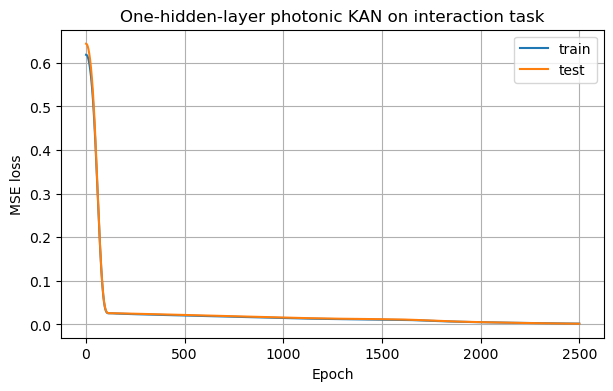

In [36]:
plt.figure(figsize=(7, 4))
plt.plot(train_losses_hidden, label="train")
plt.plot(test_losses_hidden, label="test")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("One-hidden-layer photonic KAN on interaction task")
plt.legend()
plt.grid(True)
plt.show()

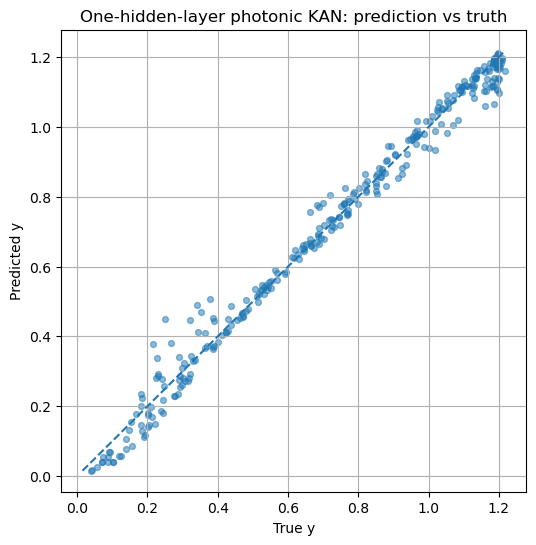

In [37]:
model_hidden_photonic.eval()

with torch.no_grad():
    y_pred_test = model_hidden_photonic(x_test)

plt.figure(figsize=(6, 6))
plt.scatter(y_test[:, 0].numpy(), y_pred_test[:, 0].numpy(), alpha=0.5, s=18)

minv = min(y_test.min().item(), y_pred_test.min().item())
maxv = max(y_test.max().item(), y_pred_test.max().item())

plt.plot([minv, maxv], [minv, maxv], linestyle="--")
plt.xlabel("True y")
plt.ylabel("Predicted y")
plt.title("One-hidden-layer photonic KAN: prediction vs truth")
plt.grid(True)
plt.show()

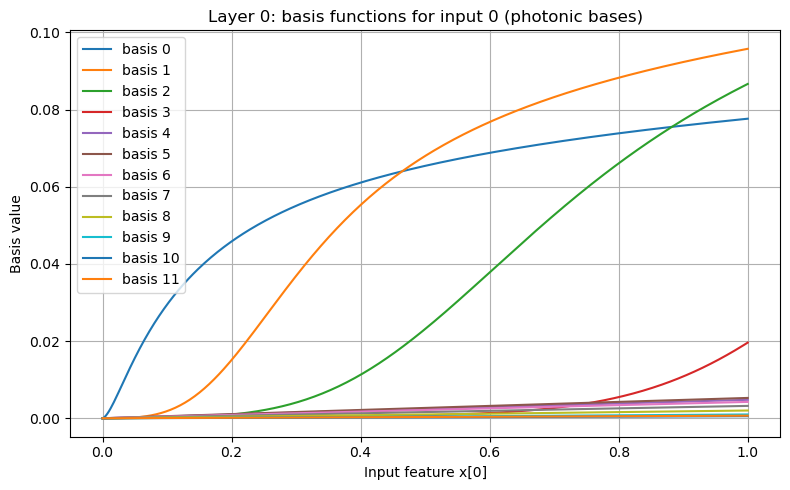

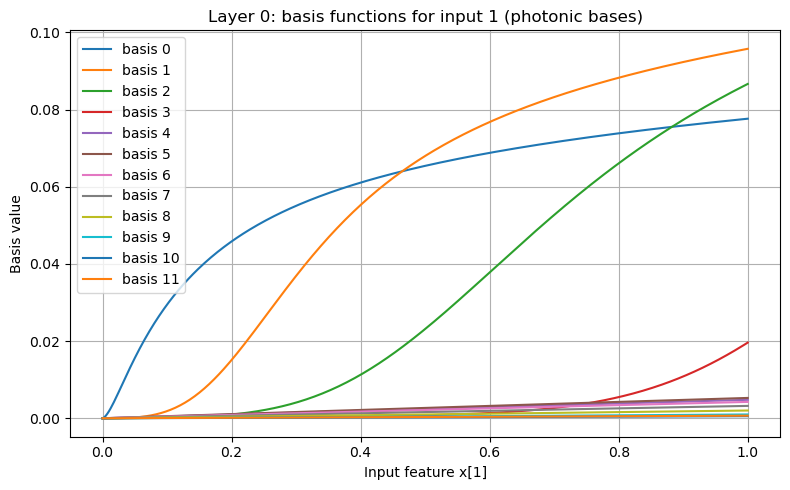

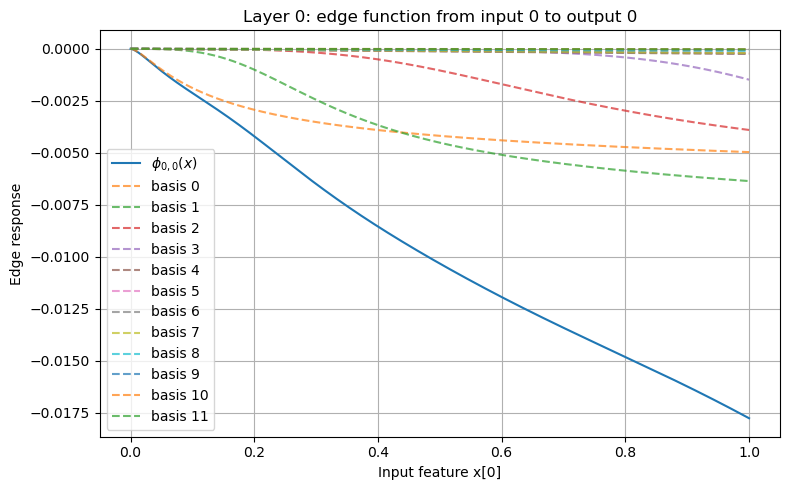

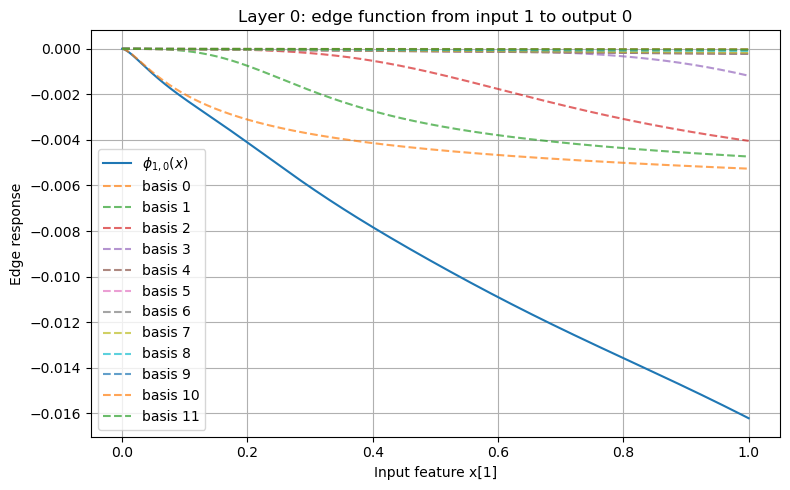

In [38]:
# First layer basis functions over original input range
model_hidden_photonic.plot_basis_functions(
    layer_idx=0,
    in_idx=0,
    x_range=(0.0, 1.0),
)

model_hidden_photonic.plot_basis_functions(
    layer_idx=0,
    in_idx=1,
    x_range=(0.0, 1.0),
)

# First layer learned edge functions
model_hidden_photonic.plot_edge_function(
    layer_idx=0,
    out_idx=0,
    in_idx=0,
    x_range=(0.0, 1.0),
    show_basis=True,
)

model_hidden_photonic.plot_edge_function(
    layer_idx=0,
    out_idx=0,
    in_idx=1,
    x_range=(0.0, 1.0),
    show_basis=True,
)

In [39]:
model_hidden_photonic.eval()

with torch.no_grad():
    h1 = model_hidden_photonic.layers[0](x_train)

h1_min = float(h1.min())
h1_max = float(h1.max())

print("Final hidden output range:")
print("h1_min =", h1_min)
print("h1_max =", h1_max)

Final hidden output range:
h1_min = -0.03506328910589218
h1_max = 1.226372241973877


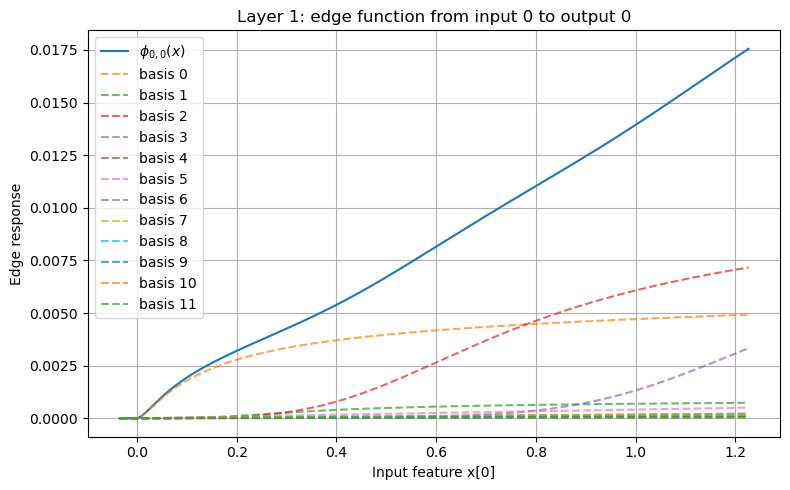

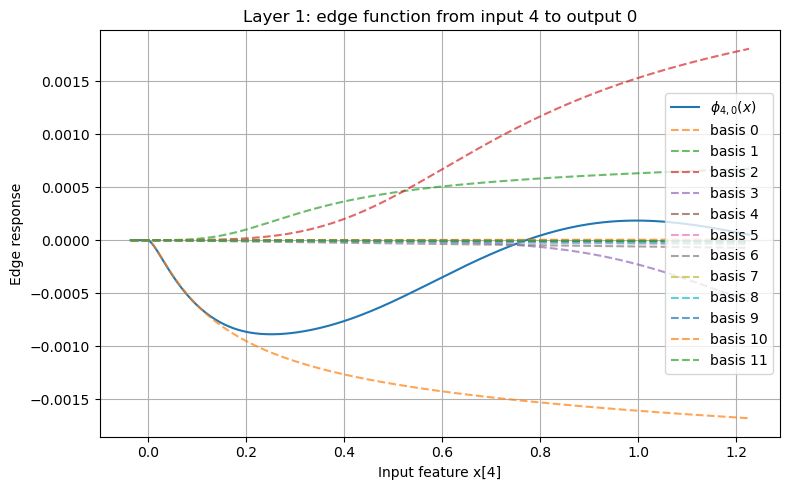

In [43]:
model_hidden_photonic.plot_edge_function(
    layer_idx=1,
    out_idx=0,
    in_idx=0,
    x_range=(h1_min, h1_max),
    show_basis=True,
)

model_hidden_photonic.plot_edge_function(
    layer_idx=1,
    out_idx=0,
    in_idx=4,
    x_range=(h1_min, h1_max),
    show_basis=True,
)

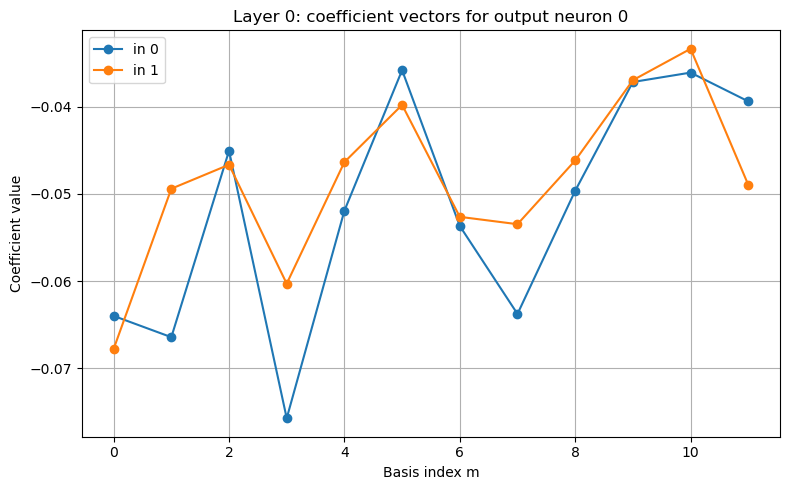

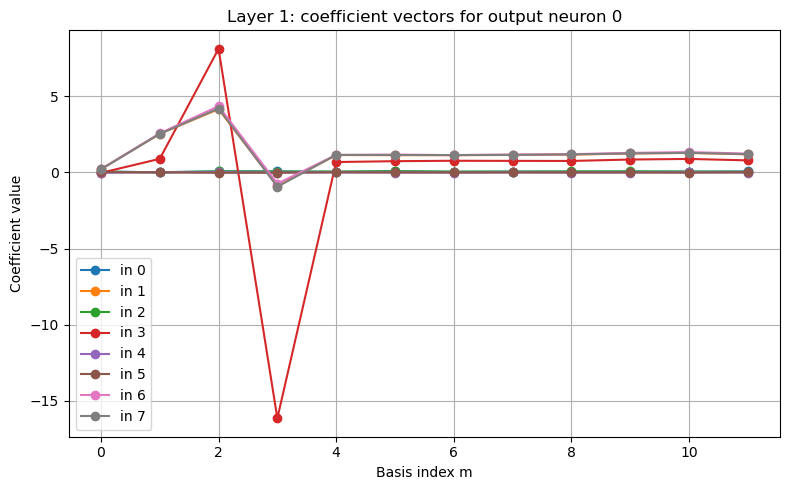

In [41]:
model_hidden_photonic.plot_all_coefficient_vectors(layer_idx=0, out_idx=0)
model_hidden_photonic.plot_all_coefficient_vectors(layer_idx=1, out_idx=0)

## Fotonska aktivacija sa afinom transformacijom

In [44]:
input_abs_max = max(abs(float(x_train.min())), abs(float(x_train.max())))
print("input_abs_max =", input_abs_max)

input_abs_max = 0.9998142123222351


In [47]:
model_hidden_interval_affine = KAN(
    in_count=2,
    out_count=1,
    hidden_layer_sizes=[8],
    layer_type="photonic_interval_affine",
    b_coef_selected=b_coef_selected,
    input_abs_max=input_abs_max,
    basis_min=0.05,
    basis_max=40.0,
    normalize_basis=True,
    debug=False,
)

In [48]:
model_hidden_interval_affine.eval()

with torch.no_grad():
    h1 = model_hidden_interval_affine.layers[0](x_train)

print("Hidden output range:")
print("min:", h1.min().item())
print("max:", h1.max().item())
print("abs max:", h1.abs().max().item())

Hidden output range:
min: nan
max: nan
abs max: nan
